In [1]:
import os
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

from matplotlib import rcParams, rcParamsDefault
import seaborn as sns 
rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'k',   
        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        
        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


sns.set_palette("colorblind")
COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLORS = ['#39729C', "#D8B66F"]



## Score 分析

In [12]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# %matplotlib inline

# === 路径设置 ===
INPUT_CSV = "extra/datasets/results/perturbation_masks_mode-all.csv"  # <- 改成你的文件
OUT_DIR   = "extra/datasets/results/analysis_value"
os.makedirs(OUT_DIR, exist_ok=True)

# 读入
df = pd.read_csv(INPUT_CSV)

# 识别 baseline：masked_marks 为空(NaN) 或 字符串"None"
is_baseline = df["masked_marks"].isna() | (df["masked_marks"] == "None")
baseline = df[is_baseline].copy()
perturb  = df[~is_baseline].copy()

# 以 (gene_id, eid, fold) 对齐 baseline 与 perturb，计算 Δscore（分别对 bs_label / bf_label）
merge_keys = ["gene_id","eid","fold"]
for target in ["bs_label","bf_label"]:
    perturb = perturb.merge(
        baseline[merge_keys + [f"{target}_score", f"{target}_label"]].rename(
            columns={f"{target}_score": f"{target}_score_base",
                     f"{target}_label": f"{target}_label_base"}
        ),
        on=merge_keys, how="left"
    )
    perturb[f"{target}_dscore"] = perturb[f"{target}_score"] - perturb[f"{target}_score_base"]

# 额外：组合阶数（单一组蛋白=1；双组合=2；…），便于筛选作图
def combo_order(s):
    if pd.isna(s) or s == "None": return 0
    return len(str(s).split("|"))
perturb["order"] = perturb["masked_marks"].map(combo_order)

print("样本量（非基线）：", len(perturb))
perturb.head()

样本量（非基线）： 5550916


,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,eid,masked_marks,mask_strength,mask_region,bs_label_score_base,bs_label_label_base,bs_label_dscore,bf_label_score_base,bf_label_label_base,bf_label_dscore,order
0,ENSG00000169184,1,0.157193,0,0,0.013129,0,0,E116,H3K4me1,0.0,all,0.297812,1,-0.140619,0.015960,0,-0.002831,1
1,ENSG00000141293,1,0.724978,1,1,0.909524,1,0,E116,H3K4me1,0.0,all,0.749037,1,-0.024059,0.898768,1,0.010756,1
2,ENSG00000171396,0,0.061521,0,0,0.002496,0,0,E116,H3K4me1,0.0,all,0.082969,0,-0.021449,0.002864,0,-0.000369,1
3,ENSG00000108433,1,0.859948,1,1,0.892916,1,0,E116,H3K4me1,0.0,all,0.834863,1,0.025085,0.938925,1,-0.046009,1
4,ENSG00000204379,0,0.090262,0,0,0.069833,0,0,E116,H3K4me1,0.0,all,0.090262,0,0.000000,0.069833,0,0.000000,1


In [13]:
def summarize_value_shift(df_perturb, target):
    """按 masked_marks × label(基线) 汇总 Δscore 的均值/标准差/样本数"""
    sub = df_perturb[[ "masked_marks", f"{target}_dscore", f"{target}_label_base" ]].dropna()
    g = (sub.groupby(["masked_marks", f"{target}_label_base"])
              [f"{target}_dscore"].agg(["mean","std","count"]).reset_index()
         ).rename(columns={f"{target}_label_base":"label"})
    g["target"] = target
    return g

summary_bs = summarize_value_shift(perturb, "bs_label")
summary_bf = summarize_value_shift(perturb, "bf_label")
summary = pd.concat([summary_bs, summary_bf], axis=0)

summary_path = os.path.join(OUT_DIR, "mask_value_shift_summary.csv")
summary.to_csv(summary_path, index=False)
print("[saved]", summary_path)

summary.head(10)

[saved] extra/datasets/results/analysis_value/mask_value_shift_summary.csv


,masked_marks,label,mean,std,count,target
0,H3K27ac,0,-0.040225,0.092732,22066,bs_label
1,H3K27ac,1,-0.086326,0.136195,21642,bs_label
2,H3K27ac|H3K9ac,0,-0.030431,0.096529,22066,bs_label
3,H3K27ac|H3K9ac,1,-0.099099,0.129197,21642,bs_label
4,H3K27me3,0,0.045499,0.091605,22066,bs_label
5,H3K27me3,1,0.016576,0.075659,21642,bs_label
6,H3K27me3|H3K27ac,0,0.005108,0.139335,22066,bs_label
7,H3K27me3|H3K27ac,1,-0.063676,0.165322,21642,bs_label
8,H3K27me3|H3K27ac|H3K9ac,0,0.011308,0.123956,22066,bs_label
9,H3K27me3|H3K27ac|H3K9ac,1,-0.073960,0.142241,21642,bs_label


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_80728/407049947.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


[saved] extra/datasets/figures/v6/Supplementary_Figure5_perturbation_highbf.eps


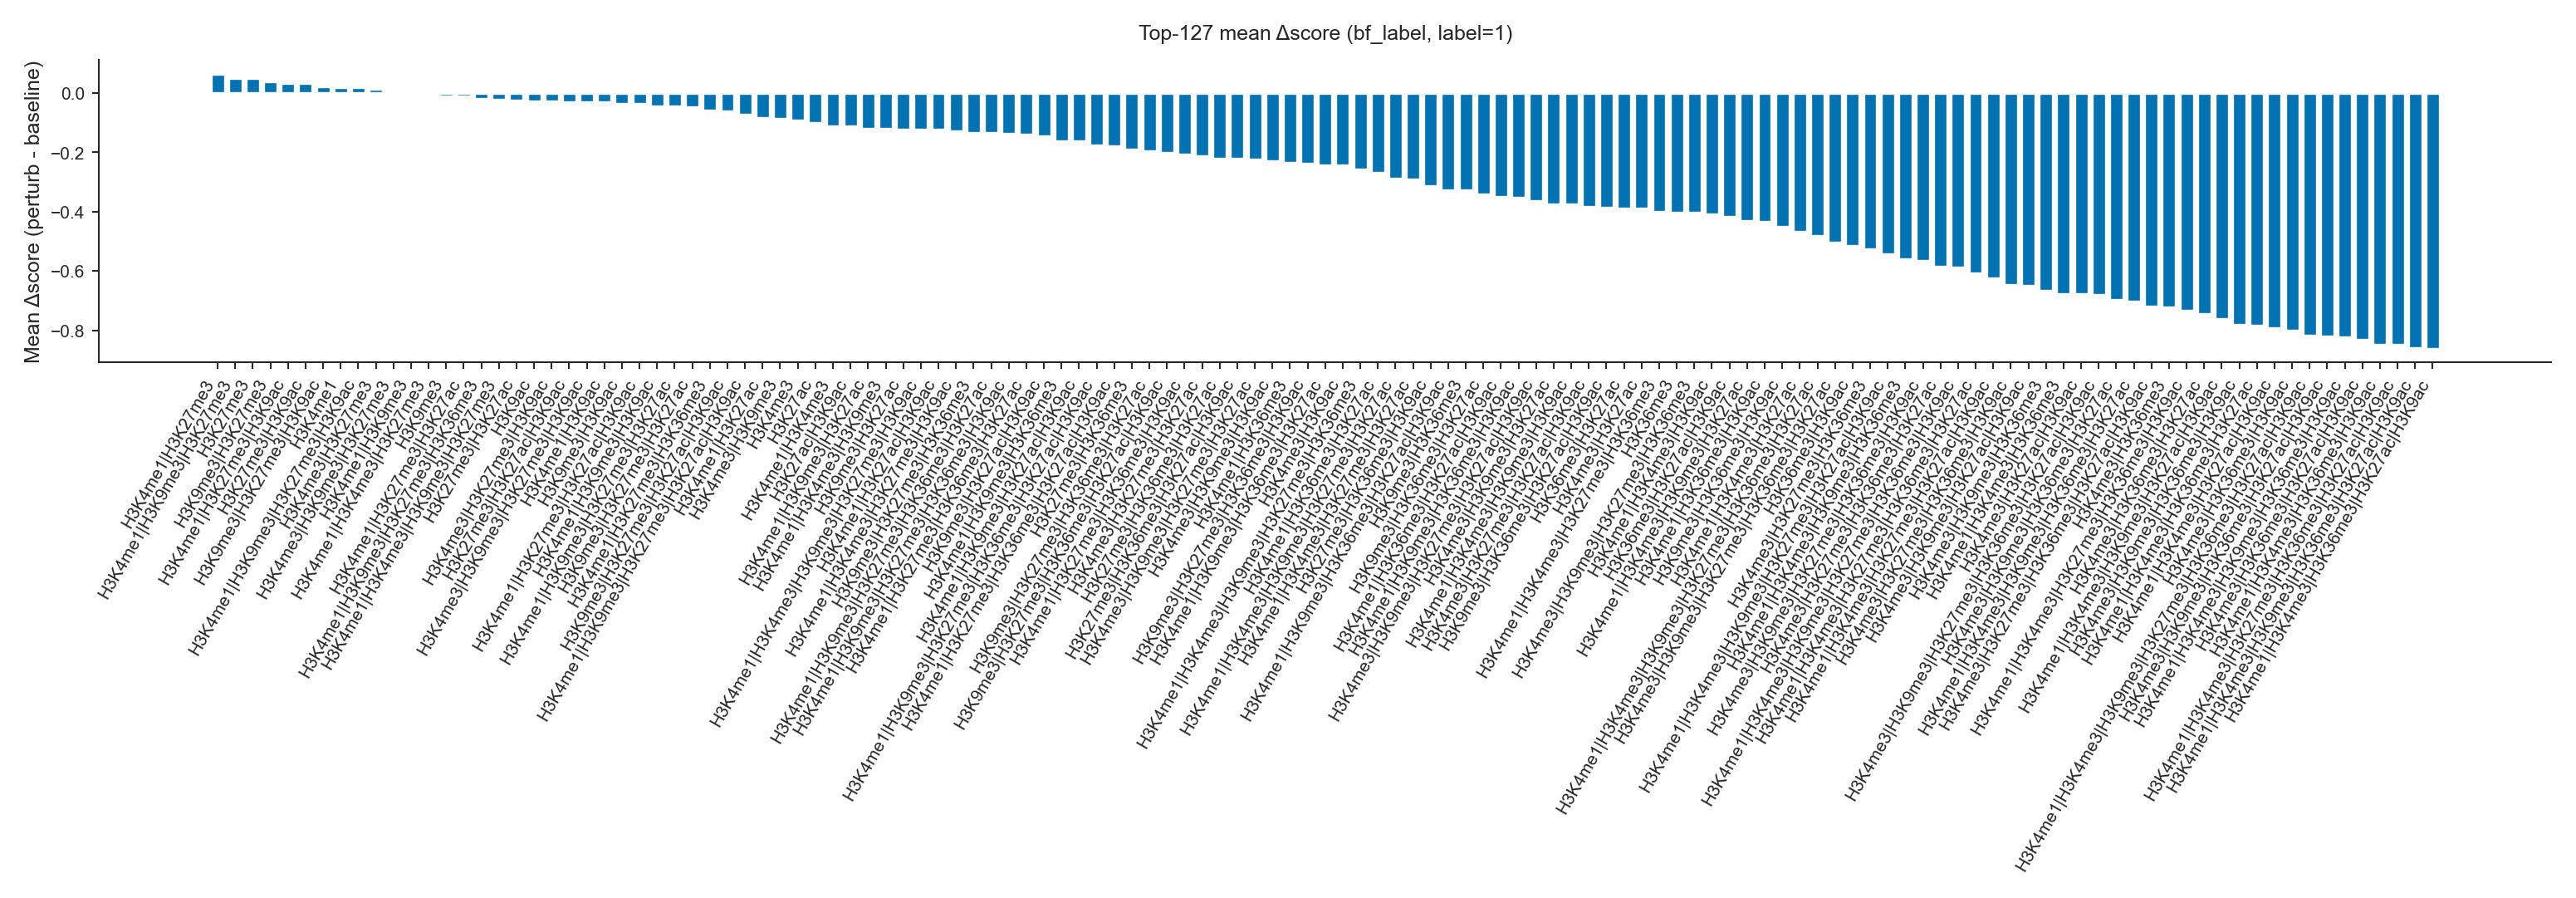

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_80728/407049947.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


[saved] extra/datasets/figures/v6/Supplementary_Figure5_perturbation_lowbf.eps


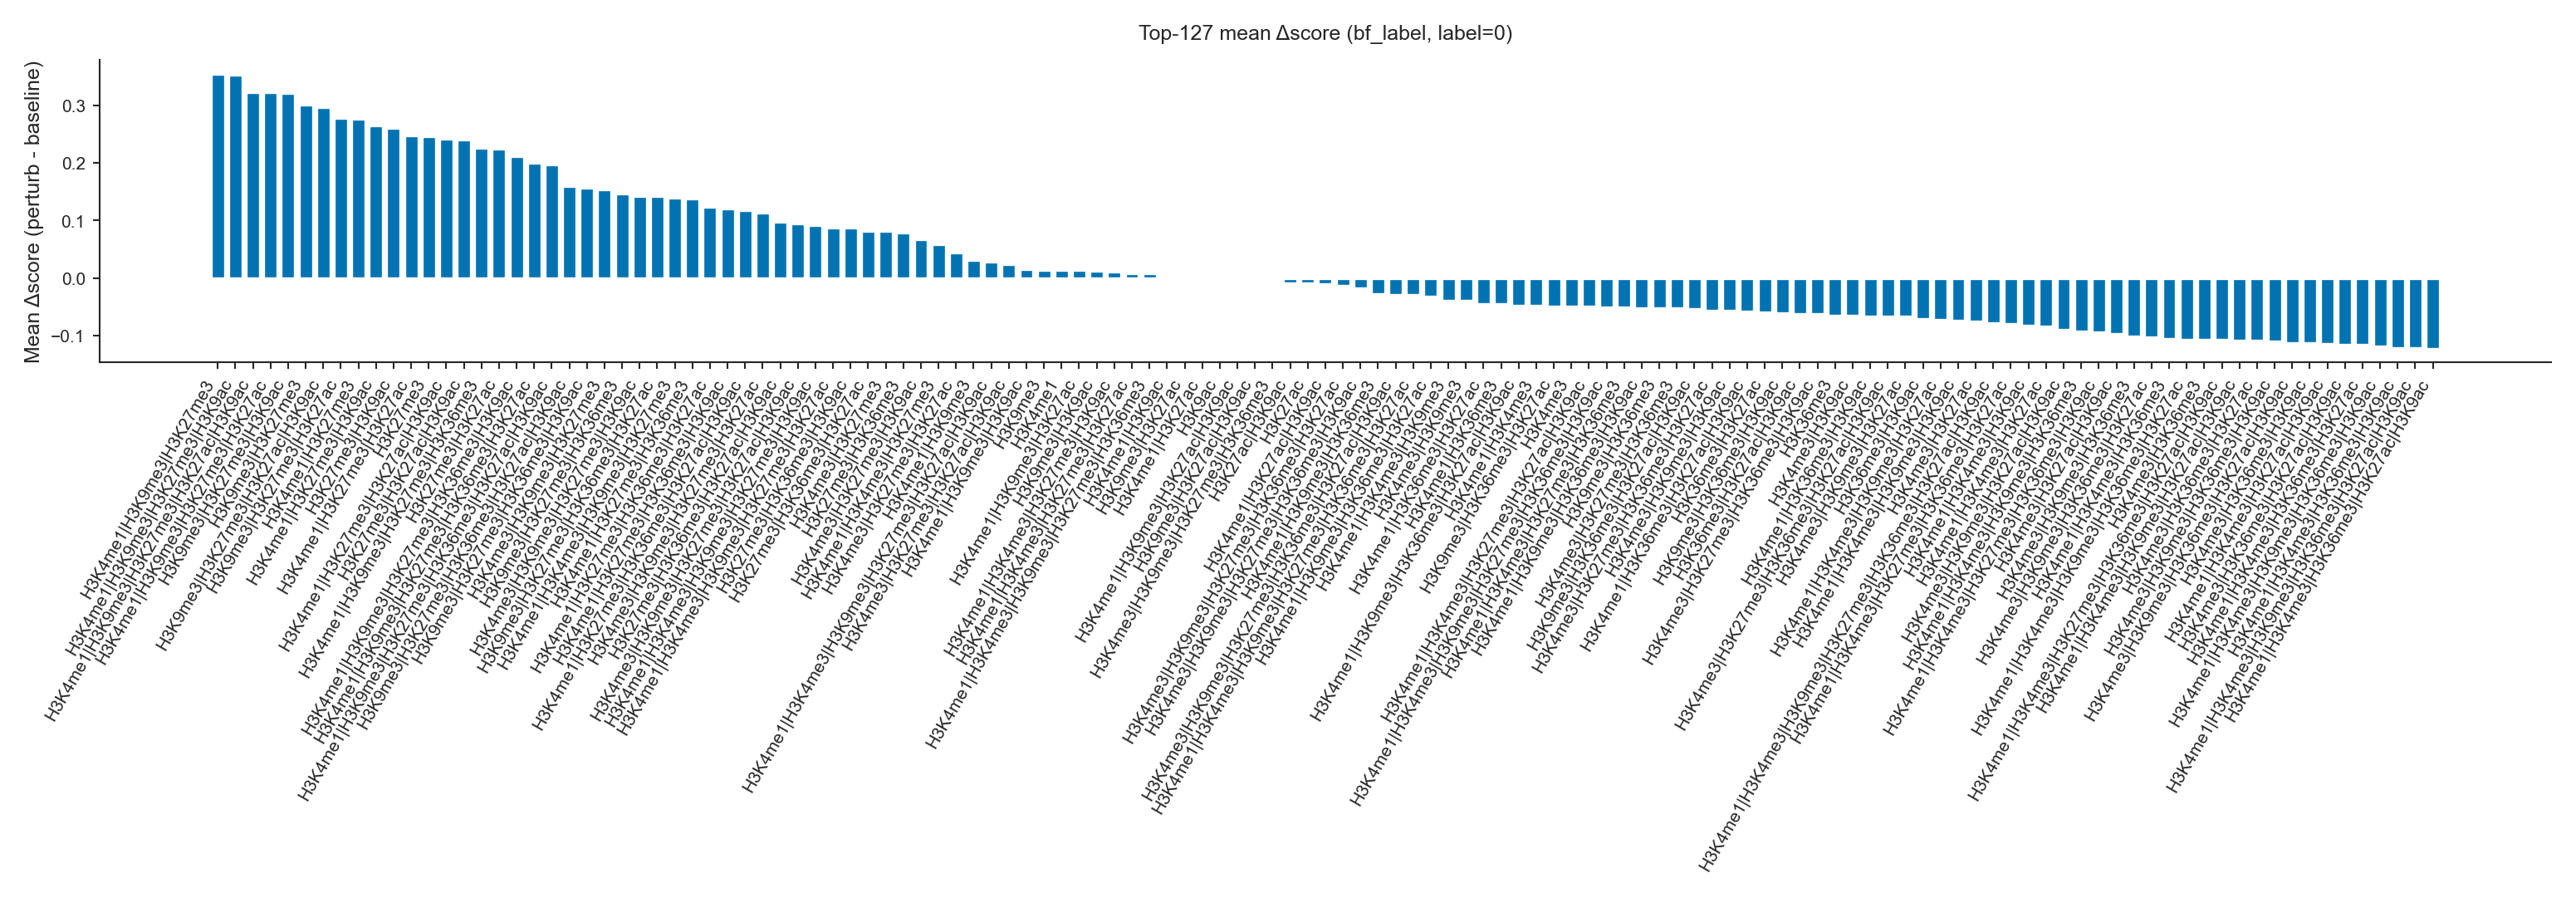

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_80728/407049947.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


[saved] extra/datasets/figures/v6/Supplementary_Figure5_perturbation_highbs.eps


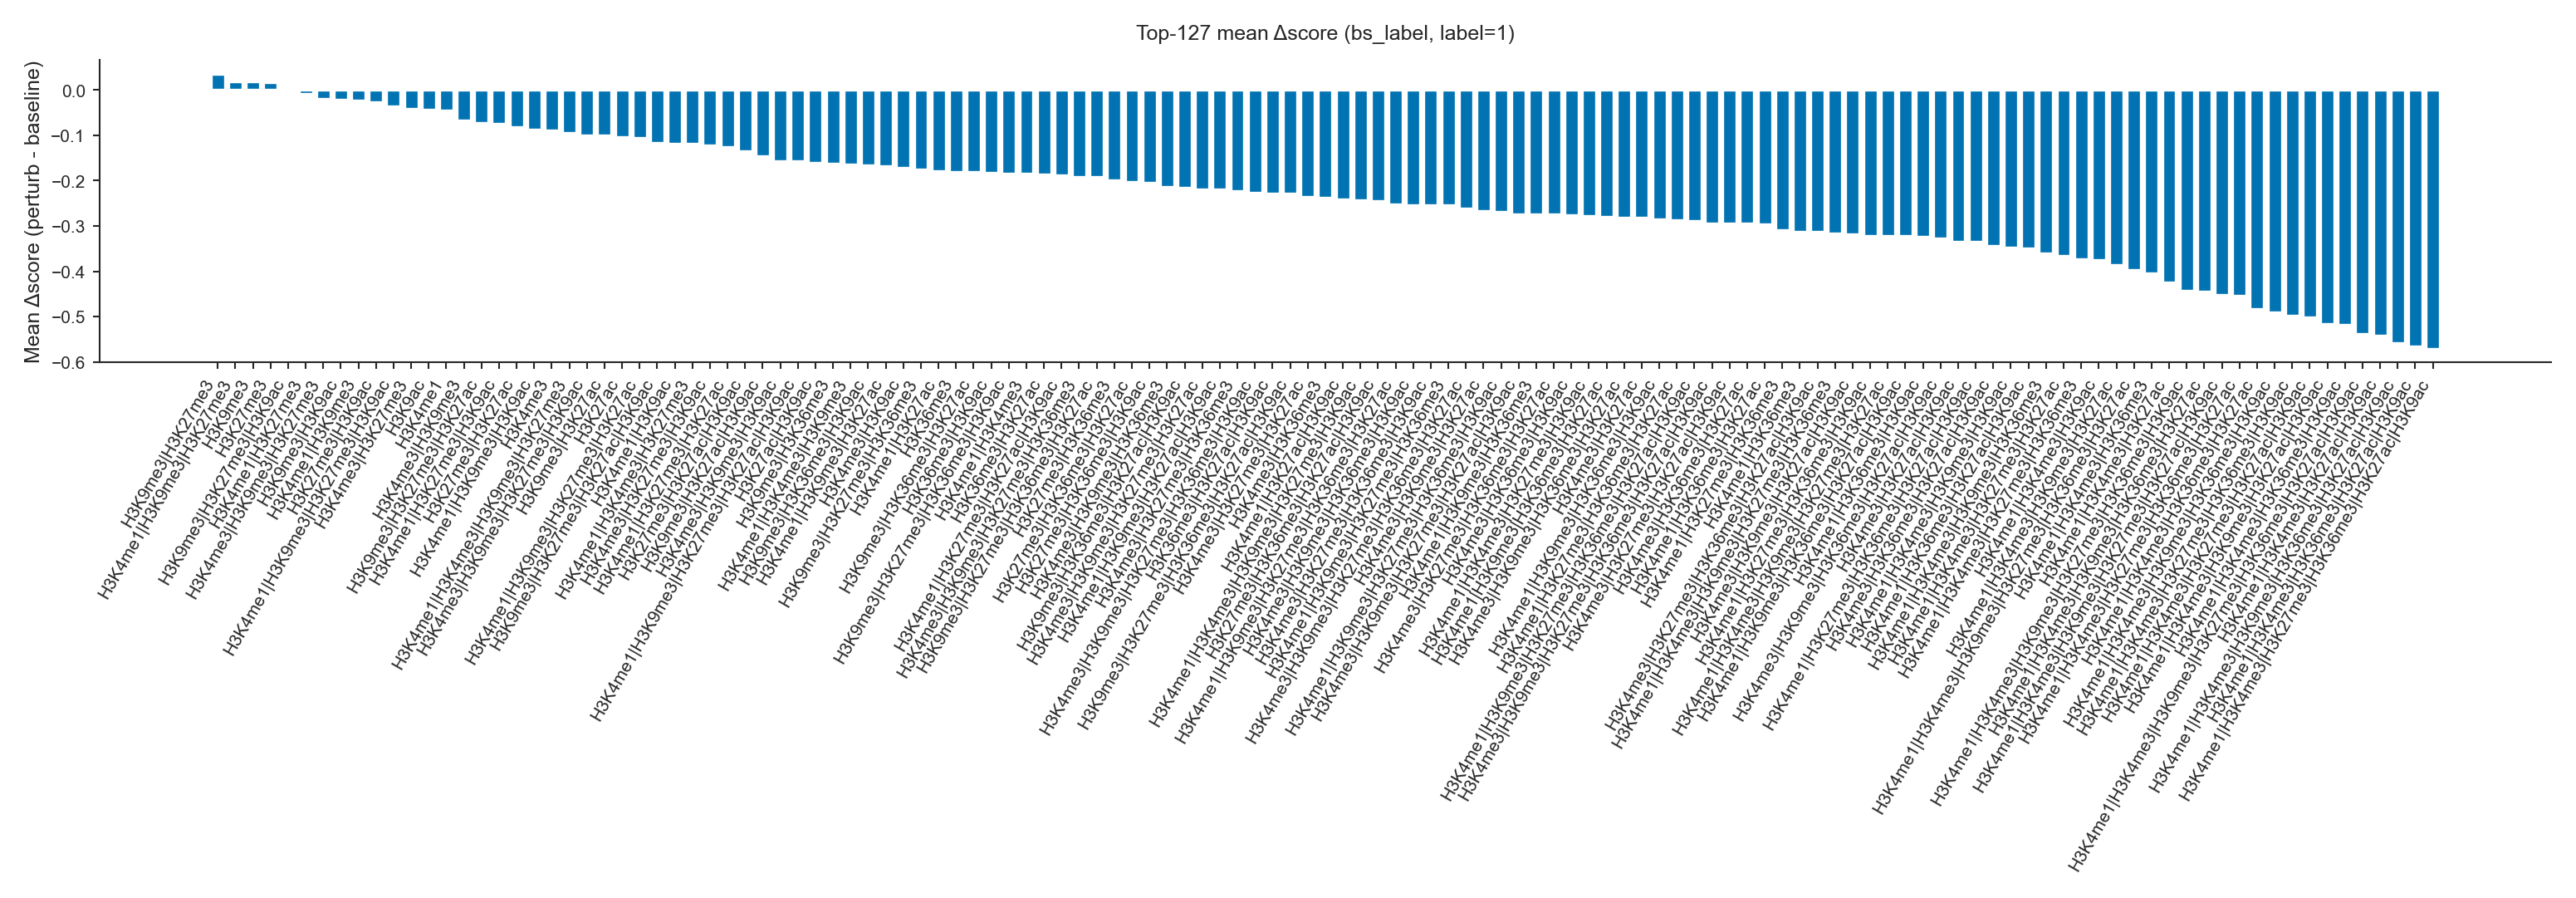

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_80728/407049947.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


[saved] extra/datasets/figures/v6/Supplementary_Figure5_perturbation_lowbs.eps


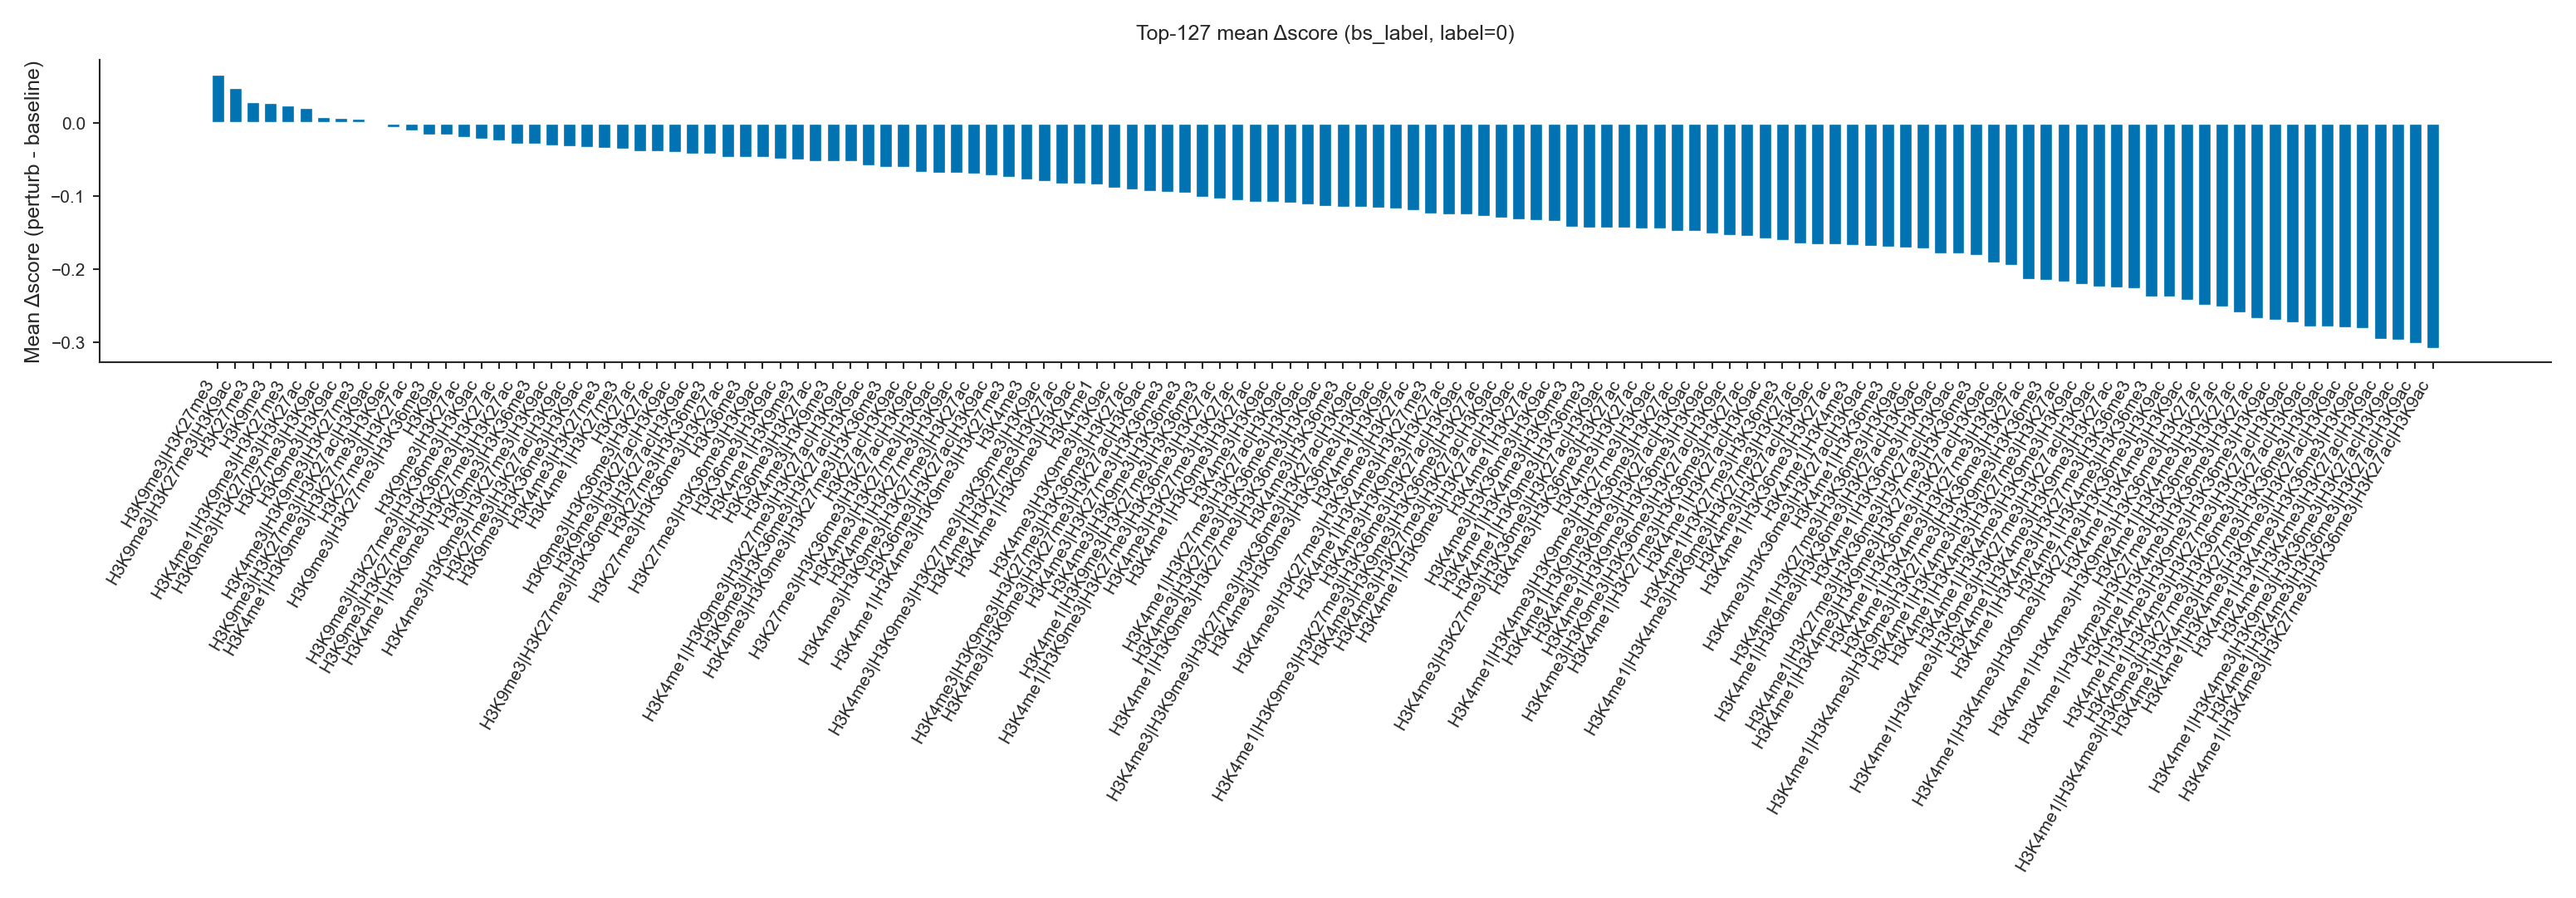

In [14]:
TOPN = 127     # 展示的组合数量
TARGET = "bf_label"  # 也可改 "bs_label"

def bar_topN_mean_dscore(df_perturb, target, label, topn=20,save_path=None):
    sub = df_perturb[df_perturb[f"{target}_label_base"]==label]
    mean_table = (sub.groupby("masked_marks")[f"{target}_dscore"]
                  .mean().sort_values(ascending=False))
    top = mean_table.head(topn)
    plt.figure(figsize=(max(8, topn*0.1)*2.54/2.54, 4/2.54))
    plt.bar(range(len(top)), top.values)
    plt.xticks(range(len(top)), top.index, rotation=60, ha="right")
    plt.title(f"Top-{topn} mean Δscore ({target}, label={label})")
    plt.ylabel("Mean Δscore (perturb - baseline)")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path,format='eps', bbox_inches='tight')
        print("[saved]", save_path)
    plt.show()

perturb = perturb[perturb['eid']=='E116']
saved_path = 'extra/datasets/figures/v6/Supplementary_Figure5_perturbation_highbf.eps'
bar_topN_mean_dscore(perturb, TARGET, label=1, topn=TOPN,save_path=saved_path)  # 高爆发
saved_path = 'extra/datasets/figures/v6/Supplementary_Figure5_perturbation_lowbf.eps'
bar_topN_mean_dscore(perturb, TARGET, label=0, topn=TOPN,save_path=saved_path)  # 低爆发


# TOPN = 127     # 展示的组合数量
TARGET = "bs_label"  # 也可改 "bs_label"
saved_path = 'extra/datasets/figures/v6/Supplementary_Figure5_perturbation_highbs.eps'
bar_topN_mean_dscore(perturb, TARGET, label=1, topn=TOPN,save_path=saved_path)  # 高爆发
saved_path = 'extra/datasets/figures/v6/Supplementary_Figure5_perturbation_lowbs.eps'
bar_topN_mean_dscore(perturb, TARGET, label=0, topn=TOPN,save_path=saved_path)  # 低爆发

## Region perturbation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_csv("extra/datasets/results/slide_perturbation_500bp_k1_s1_ALL_MARKS.csv")

# 以 BS 为例，统计不同标签的平均预测值
agg_bs = (df.groupby(["eid","fold","bin_start","bs_label_label"])
            ["bs_label_score"]
            .mean()
            .reset_index())

# 转换为宽表，便于比较 label=0 vs label=1
pivot_bs = agg_bs.pivot_table(index=["eid","fold","bin_start"],
                              columns="bs_label_label",
                              values="bs_label_score").reset_index()
pivot_bs = pivot_bs.rename(columns={0:"bs_neg_mean", 1:"bs_pos_mean"})
pivot_bs["bs_diff"] = pivot_bs["bs_pos_mean"] - pivot_bs["bs_neg_mean"]

# 同样计算 BF
agg_bf = (df.groupby(["eid","fold","bin_start","bf_label_label"])
            ["bf_label_score"]
            .mean()
            .reset_index())
pivot_bf = agg_bf.pivot_table(index=["eid","fold","bin_start"],
                              columns="bf_label_label",
                              values="bf_label_score").reset_index()
pivot_bf = pivot_bf.rename(columns={0:"bf_neg_mean", 1:"bf_pos_mean"})
pivot_bf["bf_diff"] = pivot_bf["bf_pos_mean"] - pivot_bf["bf_neg_mean"]

# 合并
pivot = pivot_bs.merge(pivot_bf, on=["eid","fold","bin_start"], how="outer")

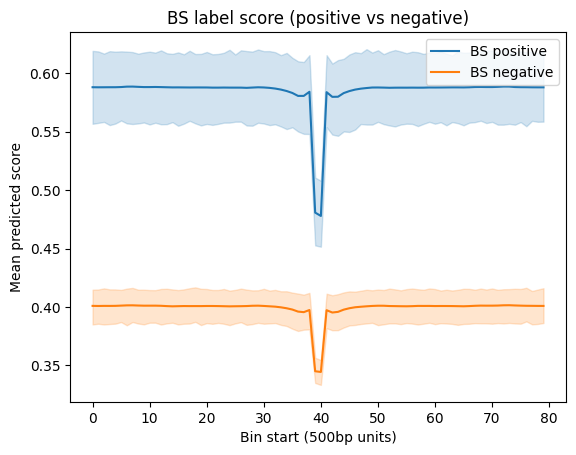

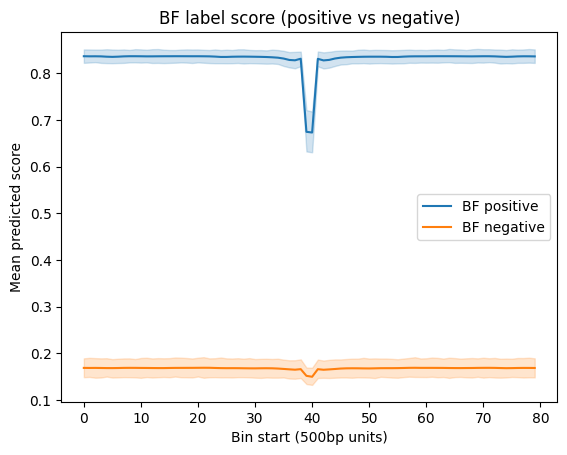

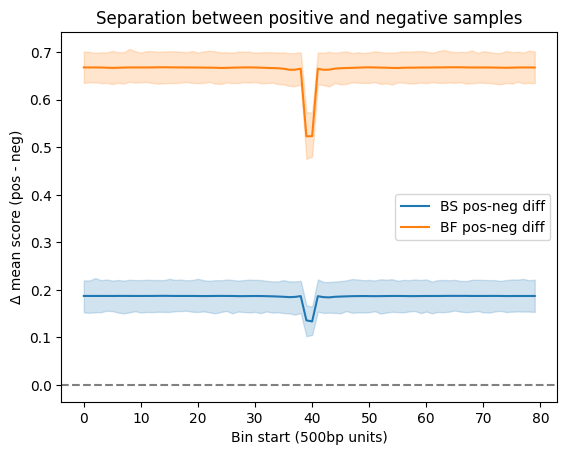

In [3]:
# ========= 可视化 =========
# plt.figure(figsize=(10,5))
sns.lineplot(data=pivot, x="bin_start", y="bs_pos_mean", label="BS positive")
sns.lineplot(data=pivot, x="bin_start", y="bs_neg_mean", label="BS negative")
plt.title("BS label score (positive vs negative)")
plt.ylabel("Mean predicted score")
plt.xlabel("Bin start (500bp units)")
plt.show()

# plt.figure(figsize=(10,5))
sns.lineplot(data=pivot, x="bin_start", y="bf_pos_mean", label="BF positive")
sns.lineplot(data=pivot, x="bin_start", y="bf_neg_mean", label="BF negative")
plt.title("BF label score (positive vs negative)")
plt.ylabel("Mean predicted score")
plt.xlabel("Bin start (500bp units)")
plt.show()

# plt.figure(figsize=(10,5))
sns.lineplot(data=pivot, x="bin_start", y="bs_diff", label="BS pos-neg diff")
sns.lineplot(data=pivot, x="bin_start", y="bf_diff", label="BF pos-neg diff")
plt.title("Separation between positive and negative samples")
plt.ylabel("Δ mean score (pos - neg)")
plt.xlabel("Bin start (500bp units)")
plt.axhline(0, color="gray", linestyle="--")
plt.show()

## 相互作用图

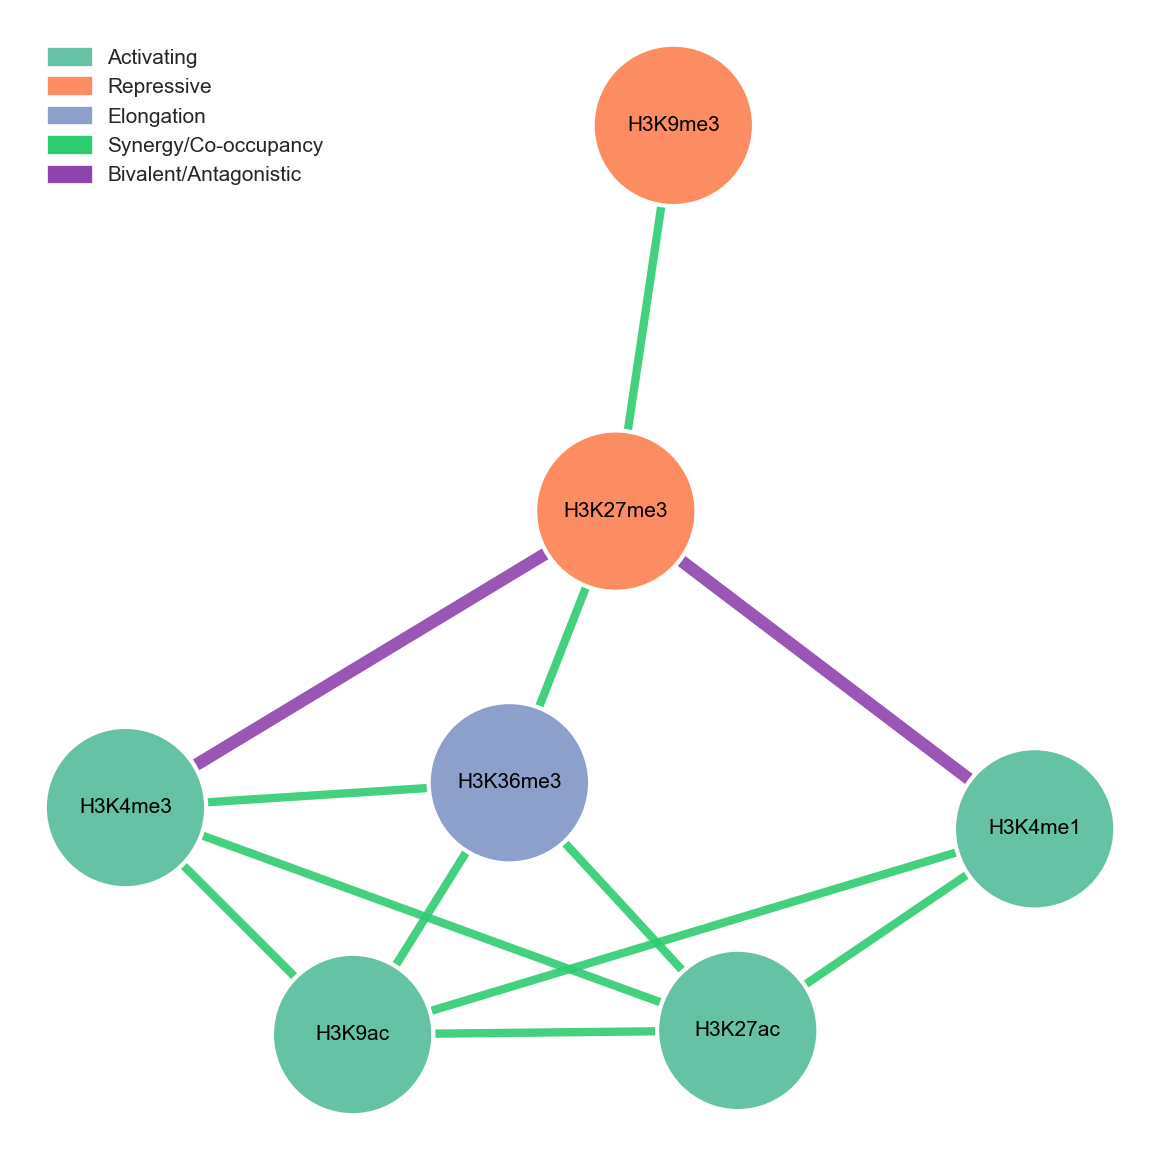

In [33]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams

# --- 定义组蛋白类别 ---
A = {"H3K4me3", "H3K27ac", "H3K9ac", "H3K4me1"}   # activating
R = {"H3K27me3", "H3K9me3"}                       # repressive
E = {"H3K36me3"}                                   # elongation

node_class = {}
for m in A: node_class[m] = "A"
for m in R: node_class[m] = "R"
for m in E: node_class[m] = "E"

# --- 支持的组合 ---
pairs_synergy = [
    ("H3K4me3","H3K9ac"),
    ("H3K4me3","H3K27ac"),
    ("H3K4me1","H3K27ac"),
    ("H3K9ac","H3K27ac"),
    ("H3K9me3","H3K27me3"),
    ("H3K4me3","H3K27me3"),
    ("H3K4me1","H3K27me3"),
    ("H3K4me3","H3K36me3"),
    ("H3K27ac","H3K36me3"),
    ("H3K9ac","H3K36me3"),
]

triples_common = [
    ("H3K4me1","H3K27ac","H3K9ac"),
    ("H3K4me3","H3K9ac","H3K27ac"),
    ("H3K4me3","H3K27me3","H3K36me3"),
]

# --- 建立图 ---
G = nx.Graph()
G.add_nodes_from(node_class.keys())
for a,b in pairs_synergy:
    G.add_edge(a,b, kind="pair")
for t in triples_common:
    for i in range(len(t)):
        for j in range(i+1,len(t)):
            if not G.has_edge(t[i], t[j]):
                G.add_edge(t[i], t[j], kind="triple")

# --- 节点样式 ---
color_map = {"A":"#66c2a5","R":"#fc8d62","E":"#8da0cb"}  # pastel配色
node_colors = [color_map[node_class[n]] for n in G.nodes]

# --- 边样式 ---
edge_colors, edge_widths = [], []
for u,v,data in G.edges(data=True):
    if (node_class[u]=="A" and node_class[v]=="R") or (node_class[u]=="R" and node_class[v]=="A"):
        edge_colors.append("#8e44ad")  # 紫色：bivalent/拮抗
        edge_widths.append(3.0)
    else:
        edge_colors.append("#2ecc71")  # 绿色：协同
        edge_widths.append(2.0)

# --- 绘制 ---
pos = nx.spring_layout(G, seed=42, k=0.6)
plt.figure(figsize=(10/2.54,10/2.54))
nx.draw_networkx_nodes(G, pos,
                       node_color=node_colors,
                       node_size=1500,
                       edgecolors="white", linewidths=1)
nx.draw_networkx_edges(G, pos,
                       edge_color=edge_colors,
                       width=edge_widths, alpha=0.9)
nx.draw_networkx_labels(G, pos,
                        font_size=5, font_family="sans-serif", font_color="black")

# 图例
legend_nodes = [mpatches.Patch(color=color_map["A"], label="Activating"),
                mpatches.Patch(color=color_map["R"], label="Repressive"),
                mpatches.Patch(color=color_map["E"], label="Elongation")]
legend_edges = [mpatches.Patch(color="#2ecc71", label="Synergy/Co-occupancy"),
                mpatches.Patch(color="#8e44ad", label="Bivalent/Antagonistic")]
plt.legend(handles=legend_nodes+legend_edges, loc="upper left", ncol=1, frameon=False, fontsize=5)

plt.axis("off")
plt.tight_layout()

# # 保存为矢量图
# plt.savefig("figures/histone_combo_network_nature.pdf", format="pdf", bbox_inches="tight")
# plt.savefig("figures/histone_combo_network_nature.eps", format="eps", bbox_inches="tight")
plt.show()

## 系统分析

### ChromHMM

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_16346/1316030558.py:97: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  disc = prob.applymap(discretize)


[Saved] ./chromhmm_E003/(prob|level).csv/.xlsx


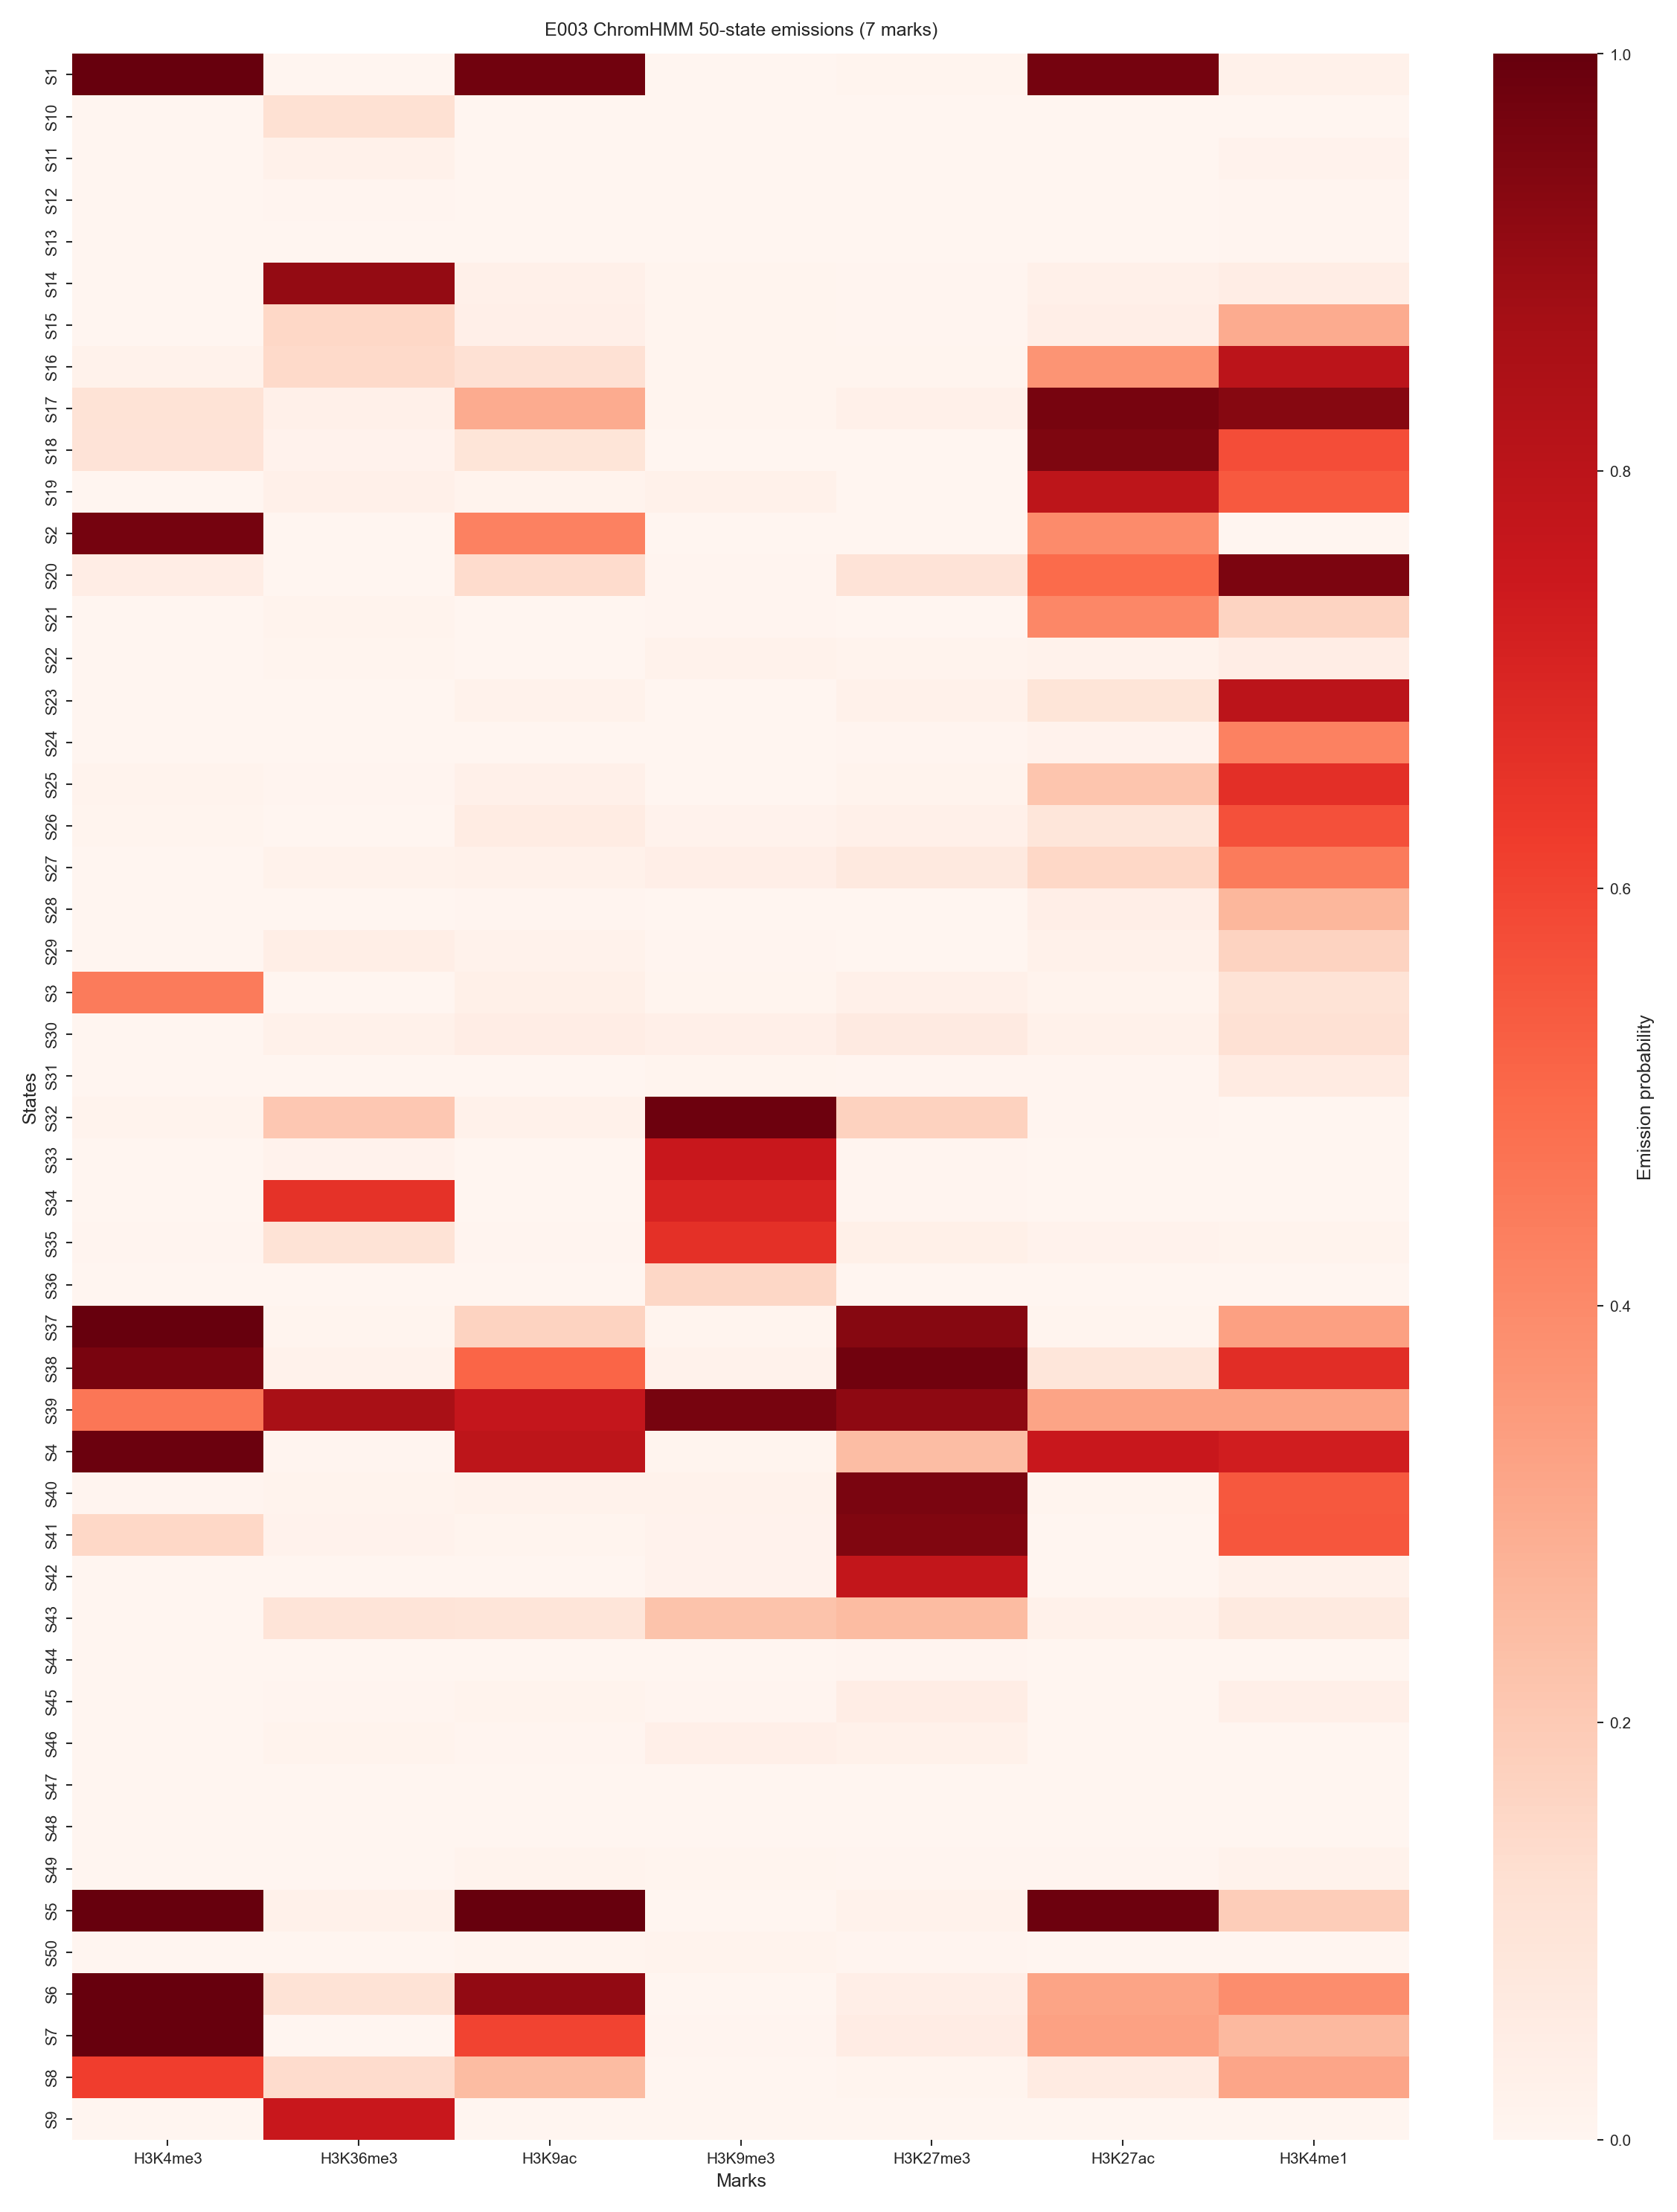

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_16346/1316030558.py:117: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  disc_num = disc.replace(level_map)


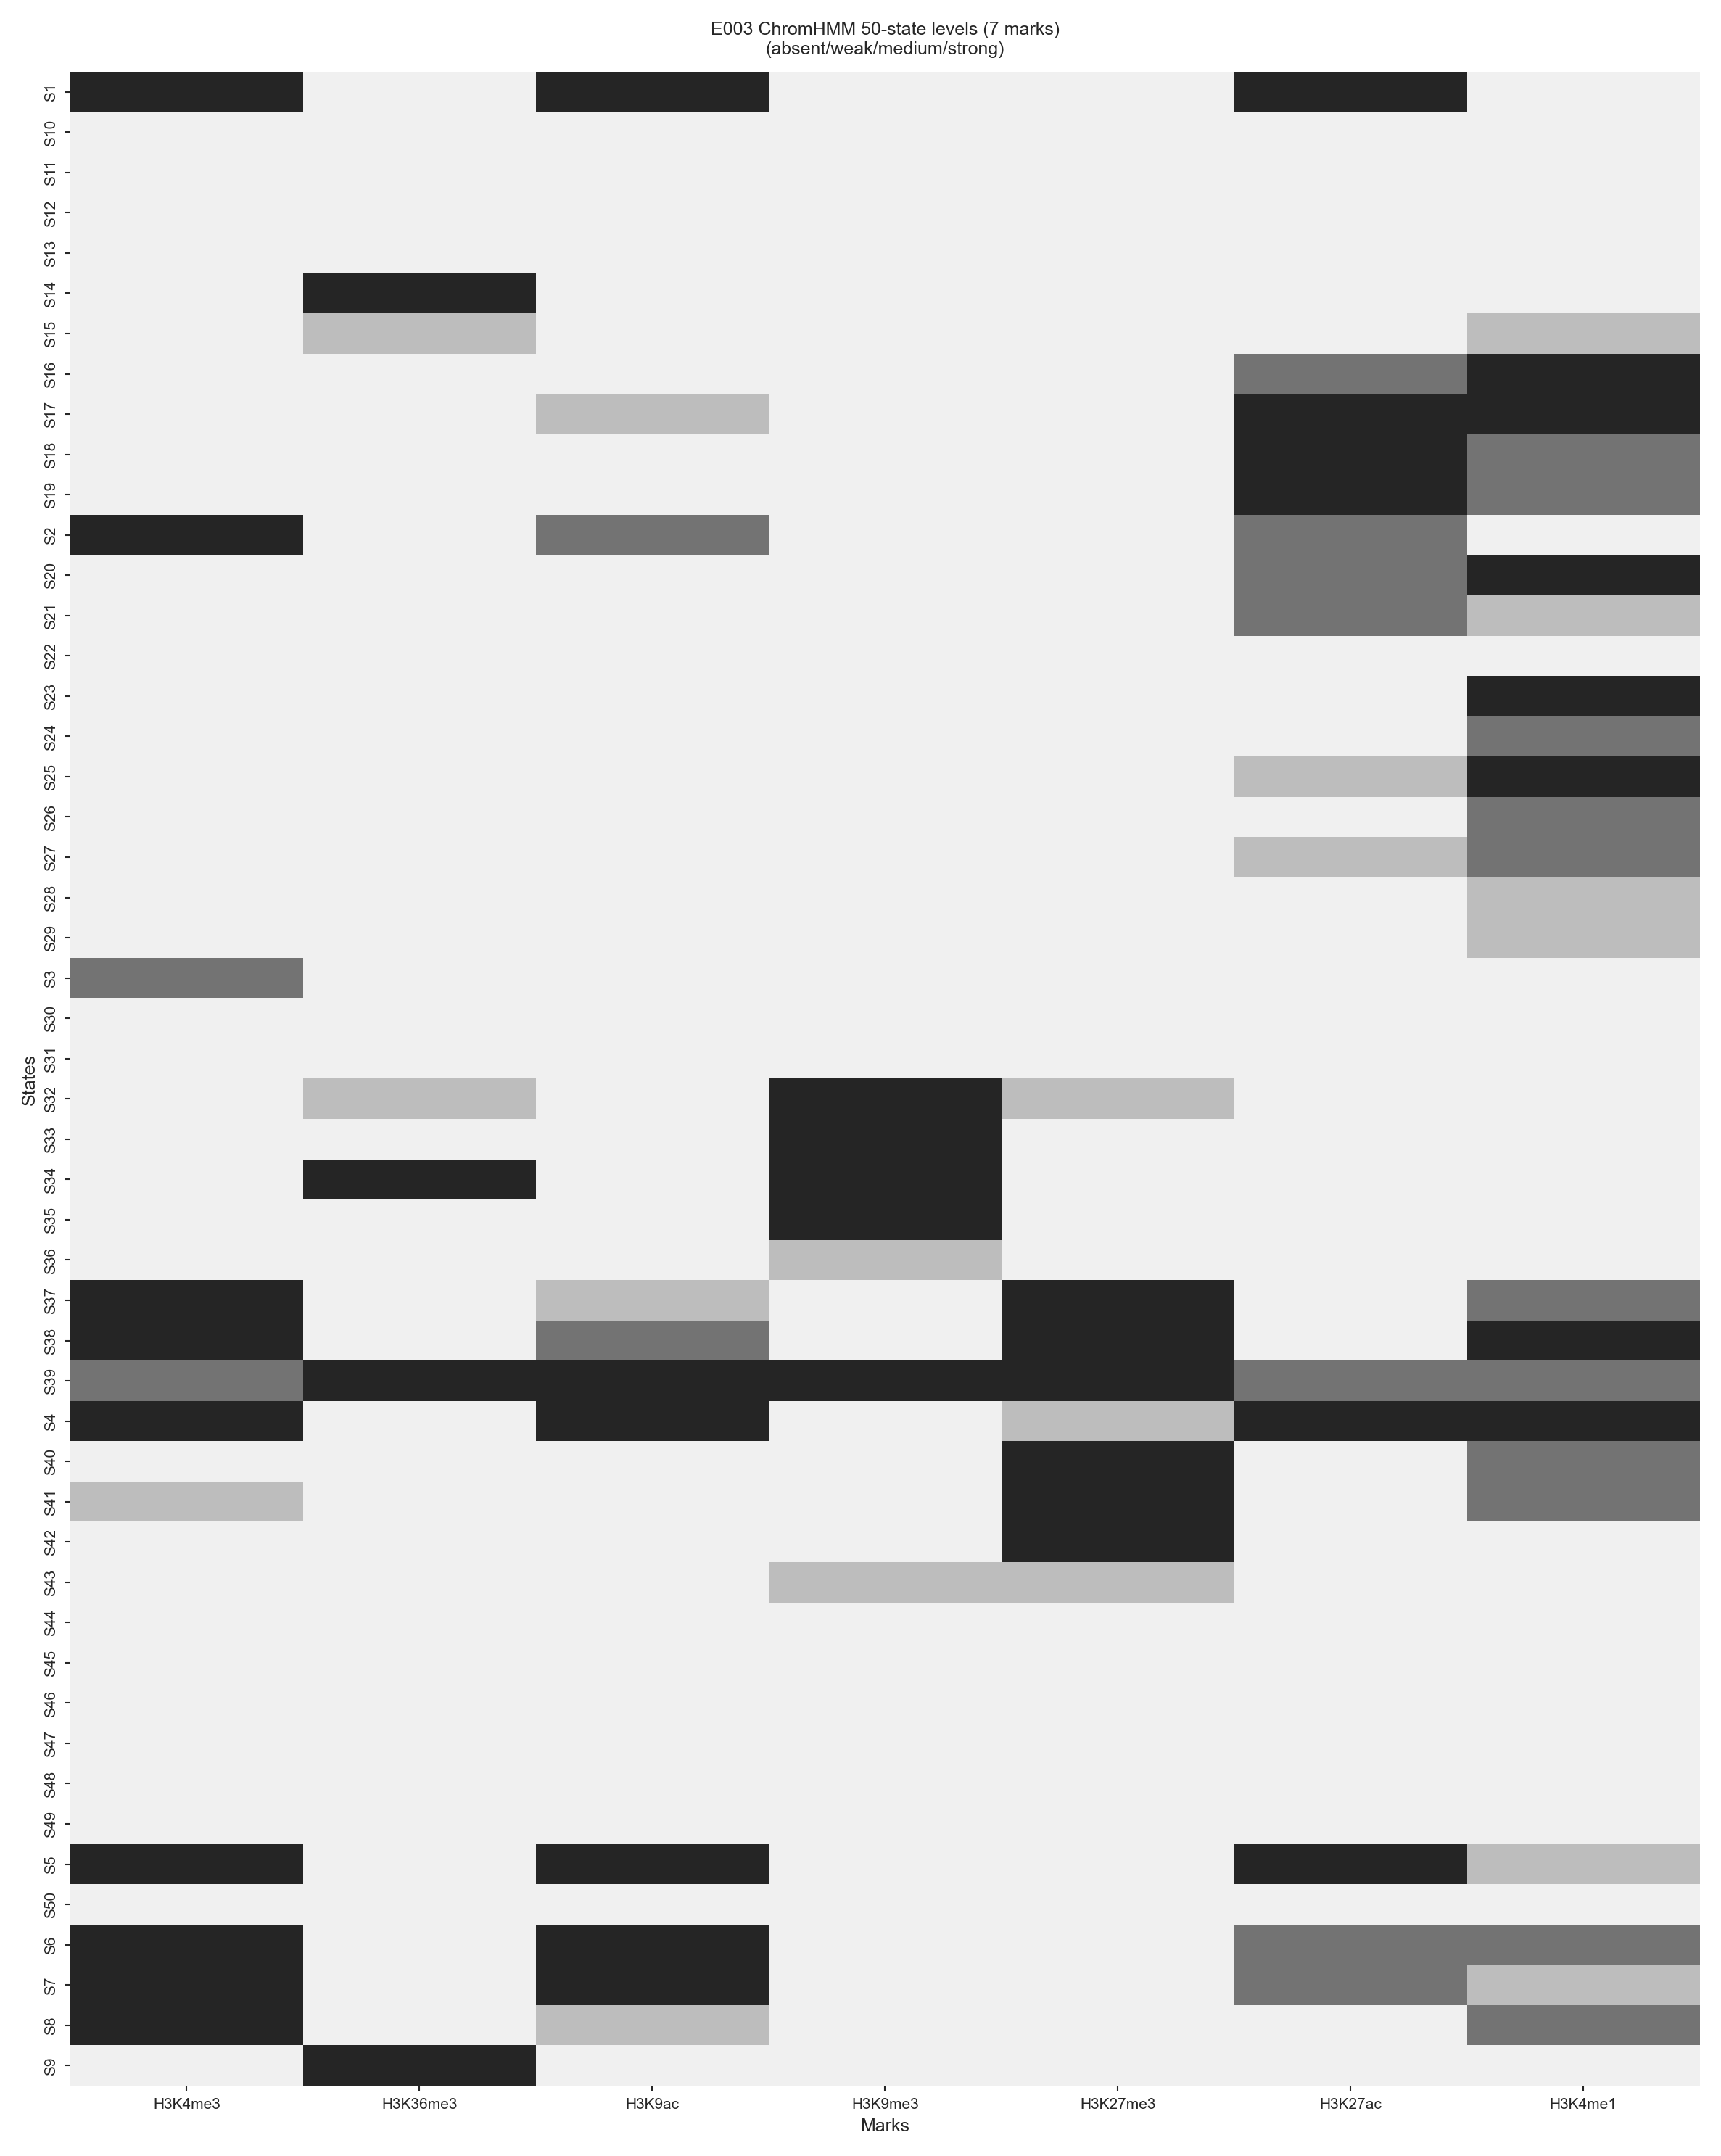

,H3K4me3,H3K36me3,H3K9ac,H3K9me3,H3K27me3,H3K27ac,H3K4me1
state,,,,,,,
S1,strong,absent,strong,absent,absent,strong,absent
S10,absent,absent,absent,absent,absent,absent,absent
S11,absent,absent,absent,absent,absent,absent,absent
S12,absent,absent,absent,absent,absent,absent,absent
S13,absent,absent,absent,absent,absent,absent,absent
S14,absent,strong,absent,absent,absent,absent,absent
S15,absent,weak,absent,absent,absent,absent,weak
S16,absent,absent,absent,absent,absent,medium,strong
S17,absent,absent,weak,absent,absent,strong,strong


In [102]:
import os, io, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======= 参数 =======
EID = "E003"  # 换成你要的 epigenome，如 E116/E118/E003 等
OUT_DIR = f"./chromhmm_{EID}"
os.makedirs(OUT_DIR, exist_ok=True)

URL_BASE = f"https://egg2.wustl.edu/roadmap/data/byFileType/chromhmmSegmentations/ChmmModels/class1Models_50states/{EID}"
URL_EMISS = f"{URL_BASE}/emissions_50.txt"
URL_MODEL = f"{URL_BASE}/model_50.txt"  # 备用：列顺序/标注

# 你关心的 7 个 marks（列名要与 emission 文件里一致；有时会是 H3K4me1.H3K4me2 风格，下面会做一次“模糊匹配”）
TARGET_MARKS = ["H3K4me3","H3K36me3","H3K9ac","H3K9me3","H3K27me3","H3K27ac","H3K4me1"]

# 阈值（可按需要微调）
TH_STRONG = 0.60
TH_MEDIUM = 0.30
TH_WEAK   = 0.15

# ======= 下载 emissions_50.txt =======
def fetch_text(url):
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.text

emiss_txt = 'emissions_50.txt'
open(os.path.join(OUT_DIR, "emissions_50.txt"), "w").write(emiss_txt)

# 有的 emission 文件没有列名行；尝试智能解析
def parse_emissions(emiss_txt):
    # 先尝试带表头解析
    df = pd.read_csv(emiss_txt, sep = '\t')
    df = df.drop(['state (Emission order)'],axis=1)
    # df = df.drop('state (Emission order)')
    # 通常第一列是 state 名，其余列为各 mark 概率
    # ncols = df.shape[1]
    # cols = ["state"] + [f"mark_{i}" for i in range(1, ncols)]
    # df.columns = cols
    return df

emiss_df = parse_emissions(emiss_txt)

# ======= 清洗列名 & 找到对应的 7 marks =======
# def normalize_col(c):
#     return c.replace("/", "_").replace(".", "_").replace("-", "_")

# emiss_df.columns = [normalize_col(str(c)) for c in emiss_df.columns]

# 可能的列名包含 mark 和布尔/二值化后缀，做一次“包含式匹配”
def pick_mark_column(df_cols, mark):
    # 标准化
    m = mark.lower()
    # 直接精确匹配
    for c in df_cols:
        if c.lower() == m:
            return c
    # 含有式匹配（比如某些文件列名是 H3K4me3_Rep1 或 H3K4me3.binarized）
    candidates = [c for c in df_cols if m in c.lower()]
    # 去掉明显不是信号列的字段
    bad_tokens = ["state", "color", "name"]
    candidates = [c for c in candidates if not any(bt in c.lower() for bt in bad_tokens)]
    return candidates[0] if candidates else None

# 找出“state”列与所有 mark 列
state_col = [c for c in emiss_df.columns if c.lower().startswith("state")]
if state_col:
    state_col = state_col[0]
else:
    # 若没有显式 state 列，创建 S1..S50
    state_col = "state"
    emiss_df[state_col] = [f"S{i+1}" for i in range(len(emiss_df))]

mark_map = {}
for m in TARGET_MARKS:
    col = pick_mark_column(emiss_df.columns, m)
    if col is None:
        print(f"[WARN] 没找到列: {m}，请检查 emissions_50.txt 的列名")
    else:
        mark_map[m] = col

# 构建 50x7 的发射概率表
prob = emiss_df[[state_col] + list(mark_map.values())].copy()
prob.columns = [state_col] + list(mark_map.keys())
prob = prob.set_index(state_col).sort_index()

# ======= 段位化：强/中/弱/缺失 =======
def discretize(p):
    if p >= TH_STRONG: return "strong"
    if p >= TH_MEDIUM: return "medium"
    if p >= TH_WEAK:   return "weak"
    return "absent"

disc = prob.applymap(discretize)

# 保存表格
prob.to_csv(os.path.join(OUT_DIR, f"{EID}_chromHMM50_emissions_7marks_prob.csv"))
disc.to_csv(os.path.join(OUT_DIR, f"{EID}_chromHMM50_emissions_7marks_level.csv"))
prob.to_excel(os.path.join(OUT_DIR, f"{EID}_chromHMM50_emissions_7marks_prob.xlsx"))
disc.to_excel(os.path.join(OUT_DIR, f"{EID}_chromHMM50_emissions_7marks_level.xlsx"))
print(f"[Saved] {OUT_DIR}/(prob|level).csv/.xlsx")

# ======= 作图（正文可用）：概率热图 & 等级热图 =======
plt.figure(figsize=(8, 10))
sns.heatmap(prob, cmap="Reds", vmin=0, vmax=1, cbar_kws={"label":"Emission probability"})
plt.title(f"{EID} ChromHMM 50-state emissions (7 marks)")
plt.xlabel("Marks"); plt.ylabel("States")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"{EID}_emissions_prob_heatmap.pdf"))
plt.show()

# 等级热图：映射为 3/2/1/0 以便配色
level_map = {"absent":0, "weak":1, "medium":2, "strong":3}
disc_num = disc.replace(level_map)

plt.figure(figsize=(8, 10))
sns.heatmap(disc_num, cmap=sns.color_palette(["#f0f0f0","#bdbdbd","#737373","#252525"], as_cmap=True),
            vmin=0, vmax=3, cbar=False)
plt.title(f"{EID} ChromHMM 50-state levels (7 marks)\n(absent/weak/medium/strong)")
plt.xlabel("Marks"); plt.ylabel("States")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"{EID}_emissions_level_heatmap.pdf"))
plt.show()

# 同时输出 Markdown 友好的示例行（前 10 个状态）
display(disc)

### 组合结果分析

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_80728/1508313762.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("bwr")
/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_80728/1508313762.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


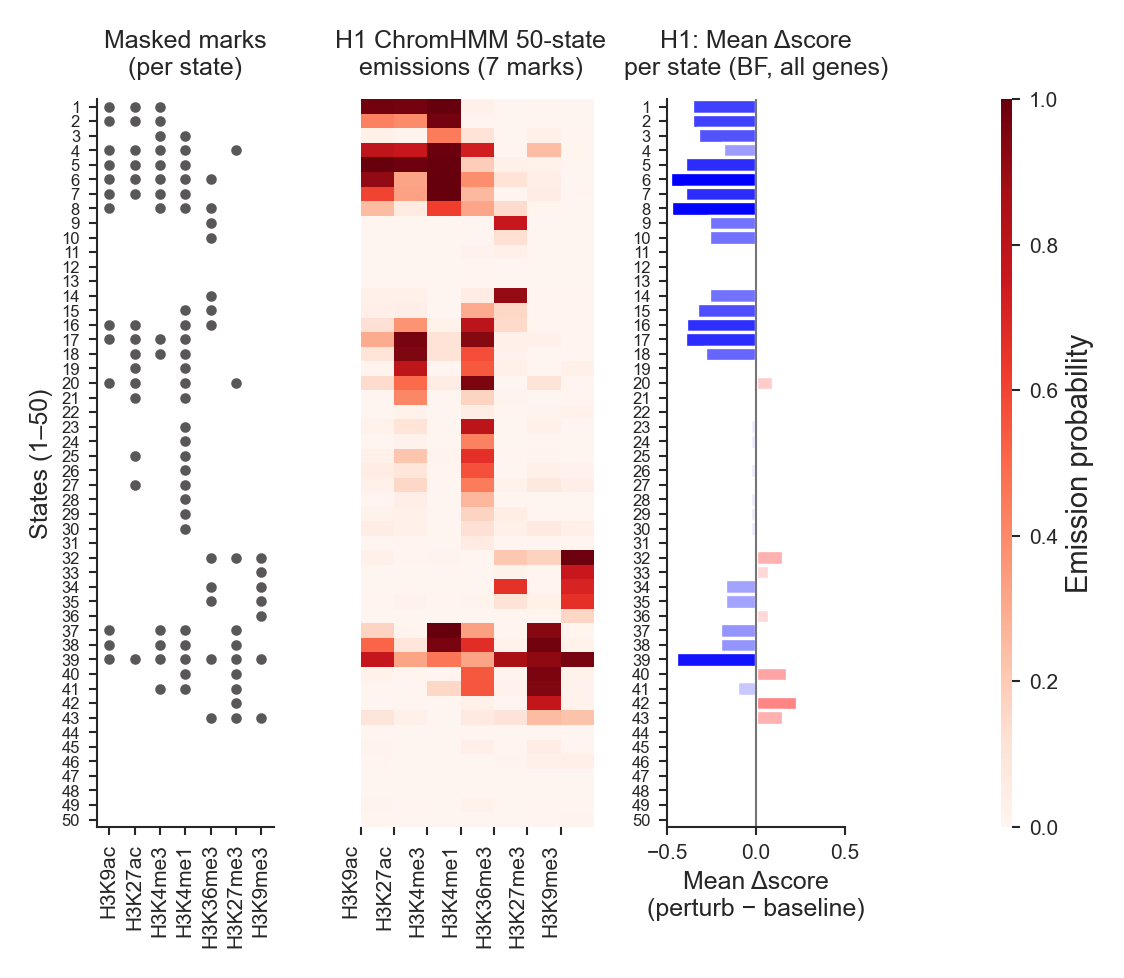

[Saved] figures_chromhmm_panels/H1_panel_ablate_emiss_bar_BF_no_delta_score.pdf


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_80728/1508313762.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap("bwr")
/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.draw()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_80728/1508313762.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


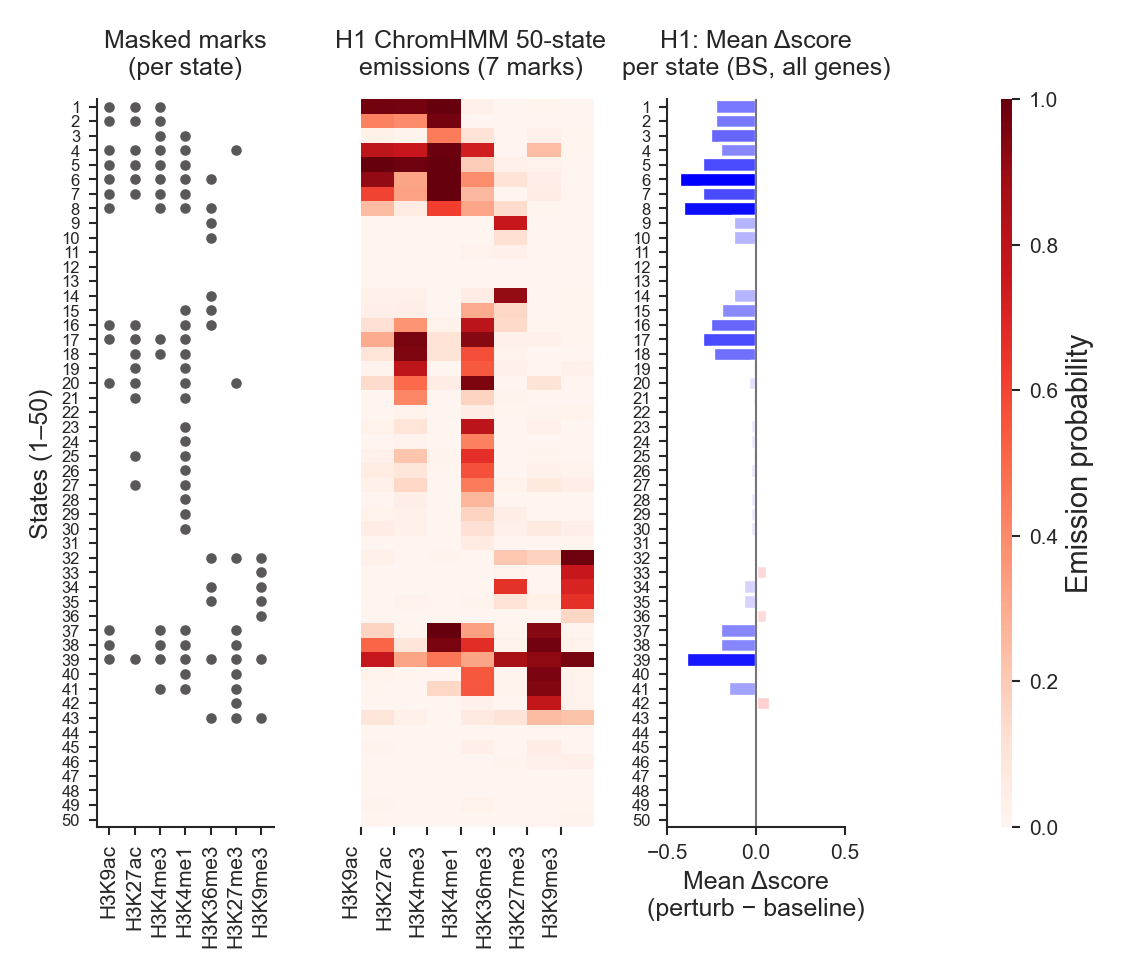

[Saved] figures_chromhmm_panels/H1_panel_ablate_emiss_bar_BS_no_delta_score.pdf
[Saved table] figures_chromhmm_panels/E003_states_dscore_overall.csv


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
import re
from matplotlib.gridspec import GridSpec 

# ========= 路径 =========
EMISS_CSV   = "chromhmm_E003/E003_chromHMM50_emissions_7marks_prob.csv"  # 50×7，行=state，列=7 marks
PERTURB_CSV = "extra/datasets/results/perturbation_masks_mode-all.csv"
OUT_DIR     = Path("figures_chromhmm_panels")
OUT_DIR.mkdir(parents=True, exist_ok=True)

marks_order = [ 'H3K9ac', 'H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
# ========= 读取 =========
emiss = pd.read_csv(EMISS_CSV, index_col=0)[marks_order]      # 可能是 S1..S50 或其它格式
perturb = pd.read_csv(PERTURB_CSV)
perturb = perturb[perturb["eid"]=="E003"].copy() # 只看 E003

# ========= 统一 state 索引为 S1..S50 =========
def to_state_label(x):
    if isinstance(x, (int, np.integer)):
        return f"S{int(x)}"
    s = str(x)
    m = re.search(r'(\d+)', s)
    if not m:
        raise ValueError(f"Cannot parse state index: {x!r}")
    return f"S{int(m.group(1))}"

emiss.index = emiss.index.map(to_state_label)
desired_states = [f"S{i}" for i in range(1, 50+1)]
# 如果 emiss 缺少部分状态，不要 reindex（避免全空）——先保持原有行序，但若包含全部 50 个则按 S1..S50 排
if set(desired_states).issubset(set(emiss.index)):
    emiss = emiss.reindex(desired_states)

# ========= 组合规范化（顺序无关） =========
def combo_to_key(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return tuple()
    if isinstance(s, str):
        s = s.strip()
        if s=="" or s.lower()=="none":
            return tuple()
        for sep in [",", " "]:
            s = s.replace(sep, "|")
        parts = [p.strip() for p in s.split("|") if p.strip()]
        return tuple(sorted(parts))
    return tuple()

perturb["combo_key"] = perturb["masked_marks"].apply(combo_to_key)

# ========= emission → 组合键（阈值法） =========
THRESH_PRESENT = 0.1
def row_to_key(row, thresh=THRESH_PRESENT):
    present = [m for m,p in row.items() if p >= thresh]
    return tuple(sorted(present)) if present else tuple()

state2key = emiss.apply(row_to_key, axis=1)  # index=S*, value=tuple()

# ========= baseline 与 Δscore（不分正负样本）=========
baseline = perturb[perturb["combo_key"]==tuple()].set_index("gene_id")
for tgt in ["bf_label","bs_label"]:
    perturb[f"{tgt}_dscore"] = perturb[f"{tgt}_score"] - perturb["gene_id"].map(baseline[f"{tgt}_score"])

# ========= 按 state 聚合 Δscore 的均值 =========
grp = {k:g for k,g in perturb.groupby("combo_key")}
rows = []
for state, key in state2key.items():
    sub = grp.get(key, pd.DataFrame())
    rows.append({
        "state": state,
        "masked_marks": "|".join(key) if key else "None",
        "bf_mean": sub["bf_label_dscore"].mean() if not sub.empty else np.nan,
        "bs_mean": sub["bs_label_dscore"].mean() if not sub.empty else np.nan,
        "n_rows": len(sub)
    })
agg = pd.DataFrame(rows).set_index("state")

# 与 emission 对齐（若 emission 有完整 S1..S50）
if set(agg.index).issuperset(set(emiss.index)):
    agg = agg.reindex(emiss.index)

# ========= 新增：构造 ablation 组合矩阵（state × marks 的 0/1） =========
# marks_order = marks_order  # 与 emission 热图一致的列顺序
ablation_bin = pd.DataFrame(0, index=emiss.index, columns=marks_order, dtype=int)
for st, combo in state2key.items():
    if st in ablation_bin.index:
        for m in combo:
            if m in ablation_bin.columns:
                ablation_bin.loc[st, m] = 1

# ========= 画图函数：最左 ablation + 中 emission + 右柱状图（单 target） =========
def panel_ablate_emiss_bar(emiss_df, agg_df, ablate_df, target_col, title, out_prefix,sorted_delta_score=True):
    # 统一索引顺序（只用三者都存在的 state，按 emiss_df 的顺序）
    states = [s for s in emiss_df.index if (s in agg_df.index and s in ablate_df.index)]
    emiss_df  = emiss_df.loc[states]
    ablate_df = ablate_df.loc[states]
    sub = agg_df.loc[states, [target_col]].copy()

    n = len(states)
    y_centers = np.arange(n) + 0.5

    # ========= 排序：按 Δscore 绝对值从大到小（保持三者一致）=========
    sub["abs_val"] = sub[target_col].abs()
    if sorted_delta_score:
        sub = sub.sort_values("abs_val", ascending=False)
    states_sorted = sub.index.tolist()
    # emiss_df  = emiss_df.loc[states_sorted]
    # ablate_df = ablate_df.loc[states_sorted]

    n = len(states_sorted)
    y_centers = np.arange(n) + 0.5

    # Δscore 颜色映射（对称）
    v = sub[target_col].to_numpy()
    vmax = np.nanmax(np.abs(v)) if np.isfinite(v).any() else 0.5
    vmax = max(vmax, 1e-3)
    norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    cmap = mpl.cm.get_cmap("bwr")

    # 画布：左(黑点) | 中(emission) | 右(柱状) | gap | colorbar
    fig = plt.figure(figsize=(10.0/2.54, 8.0/2.54))
    gs = GridSpec(
        nrows=1, ncols=5,
        width_ratios=[4.2/2.54, 6.0/2.54, 4.2/2.54, 0.4/2.54, 0.25/2.54],
        wspace=0.55, figure=fig
    )

    ax_abl = fig.add_subplot(gs[0, 0])   # ablation 组合(黑点矩阵)
    ax_left = fig.add_subplot(gs[0, 1])  # emission 热图
    ax_bar  = fig.add_subplot(gs[0, 2])  # Δscore 柱状
    ax_gap  = fig.add_subplot(gs[0, 3])  # 空白
    cax1    = fig.add_subplot(gs[0, 4])  # emission colorbar
    ax_gap.axis("off")

    # ---- 最左：ablation 黑点矩阵 ----
    ax_abl.set_xlim(-0.5, len(marks_order)-0.5)
    ax_abl.set_ylim(0, n)
    ax_abl.invert_yaxis()
    ax_abl.set_xticks(np.arange(len(marks_order)))
    ax_abl.set_xticklabels(marks_order, rotation=90)
    ax_abl.set_yticks(y_centers)
    ax_abl.set_ylabel("ChromHMM states (H1)")
    # 把 S1..S50 的前缀去掉，只显示数字
    ylab_nums = [s[1:] if isinstance(s, str) and s.startswith("S") else s for s in emiss_df.index]
    ax_abl.set_yticklabels(ylab_nums, fontsize=4)
    ax_abl.set_title("Masked marks\n(per state)")

    # 画黑点：1 的位置画一个点
    yy, xx = np.where(ablate_df.to_numpy()==1)
    ax_abl.scatter(xx, yy+0.5, s=3, c="#595757", marker="o")

    # ---- 中：emission 热图（与左侧同一 y 行）----
    hm = sns.heatmap(
        emiss_df, ax=ax_left, cmap="Reds", vmin=0, vmax=1,
        cbar=True, cbar_ax=cax1, yticklabels=True
    )
    ax_left.set_yticks([])
    ax_left.set_yticklabels([], fontsize=5)
    ax_left.set_ylim(0, n)
    ax_left.invert_yaxis()
    ax_left.set_xticks(np.arange(len(marks_order)))
    ax_left.set_xticklabels(marks_order, rotation=90)
    ax_left.set_title("H1 ChromHMM 50-state\nemissions (7 marks)")
    ax_left.set_xlabel("")
    ax_left.set_ylabel("")
    for lab in ax_left.get_xticklabels():
        lab.set_ha("right")    
    # 防止右侧标签被裁切，略扩 xlim
    nmarks = emiss_df.shape[1]
    ax_left.set_xlim(-0.5, nmarks - 0.5 + 0.6)
    cax1.set_ylabel("Emission probability", rotation=90, fontsize=7)

    # ---- 右：Δscore 柱状图（与左/中同一 y 行）----
    ax_bar.barh(y_centers, v, height=1.0, color=cmap(norm(v)))
    ax_bar.axvline(0, color="k", lw=0.5, alpha=0.6)
    ax_bar.set_ylim(0, n)
    ax_bar.set_yticks(y_centers)
    sub_states = sub.index.tolist()
    sub_states = [s[1:] if isinstance(s, str) and s.startswith("S") else s for s in sub_states]
    ax_bar.set_yticklabels(sub_states, fontsize=4)
    ax_bar.invert_yaxis()
    ax_bar.set_xlabel("Mean Δscore\n(perturb − baseline)")
    ax_bar.set_ylabel("")
    ax_bar.set_title(title)
    ax_bar.set_xlim(-0.5, 0.5)

    plt.tight_layout()
    fig.savefig(OUT_DIR / f"{out_prefix}.pdf", bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{out_prefix}.eps", format="eps", bbox_inches="tight")
    plt.show()
    print("[Saved]", OUT_DIR / f"{out_prefix}.pdf")

# ========= 分别输出 BF / BS 两套图（带 ablation 面板）=========
panel_ablate_emiss_bar(
    emiss_df=emiss,
    agg_df=agg,
    ablate_df=ablation_bin,
    target_col="bf_mean",
    title="H1: Mean Δscore\nper state (BF, all genes)",
    out_prefix="H1_panel_ablate_emiss_bar_BF_no_delta_score",
    sorted_delta_score=False
)

panel_ablate_emiss_bar(
    emiss_df=emiss,
    agg_df=agg,
    ablate_df=ablation_bin,
    target_col="bs_mean",
    title="H1: Mean Δscore\nper state (BS, all genes)",
    out_prefix="H1_panel_ablate_emiss_bar_BS_no_delta_score",
    sorted_delta_score=False
)

# 同时保存汇总表
agg.to_csv(OUT_DIR / "E003_states_dscore_overall.csv")
print("[Saved table]", OUT_DIR / "E003_states_dscore_overall.csv")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


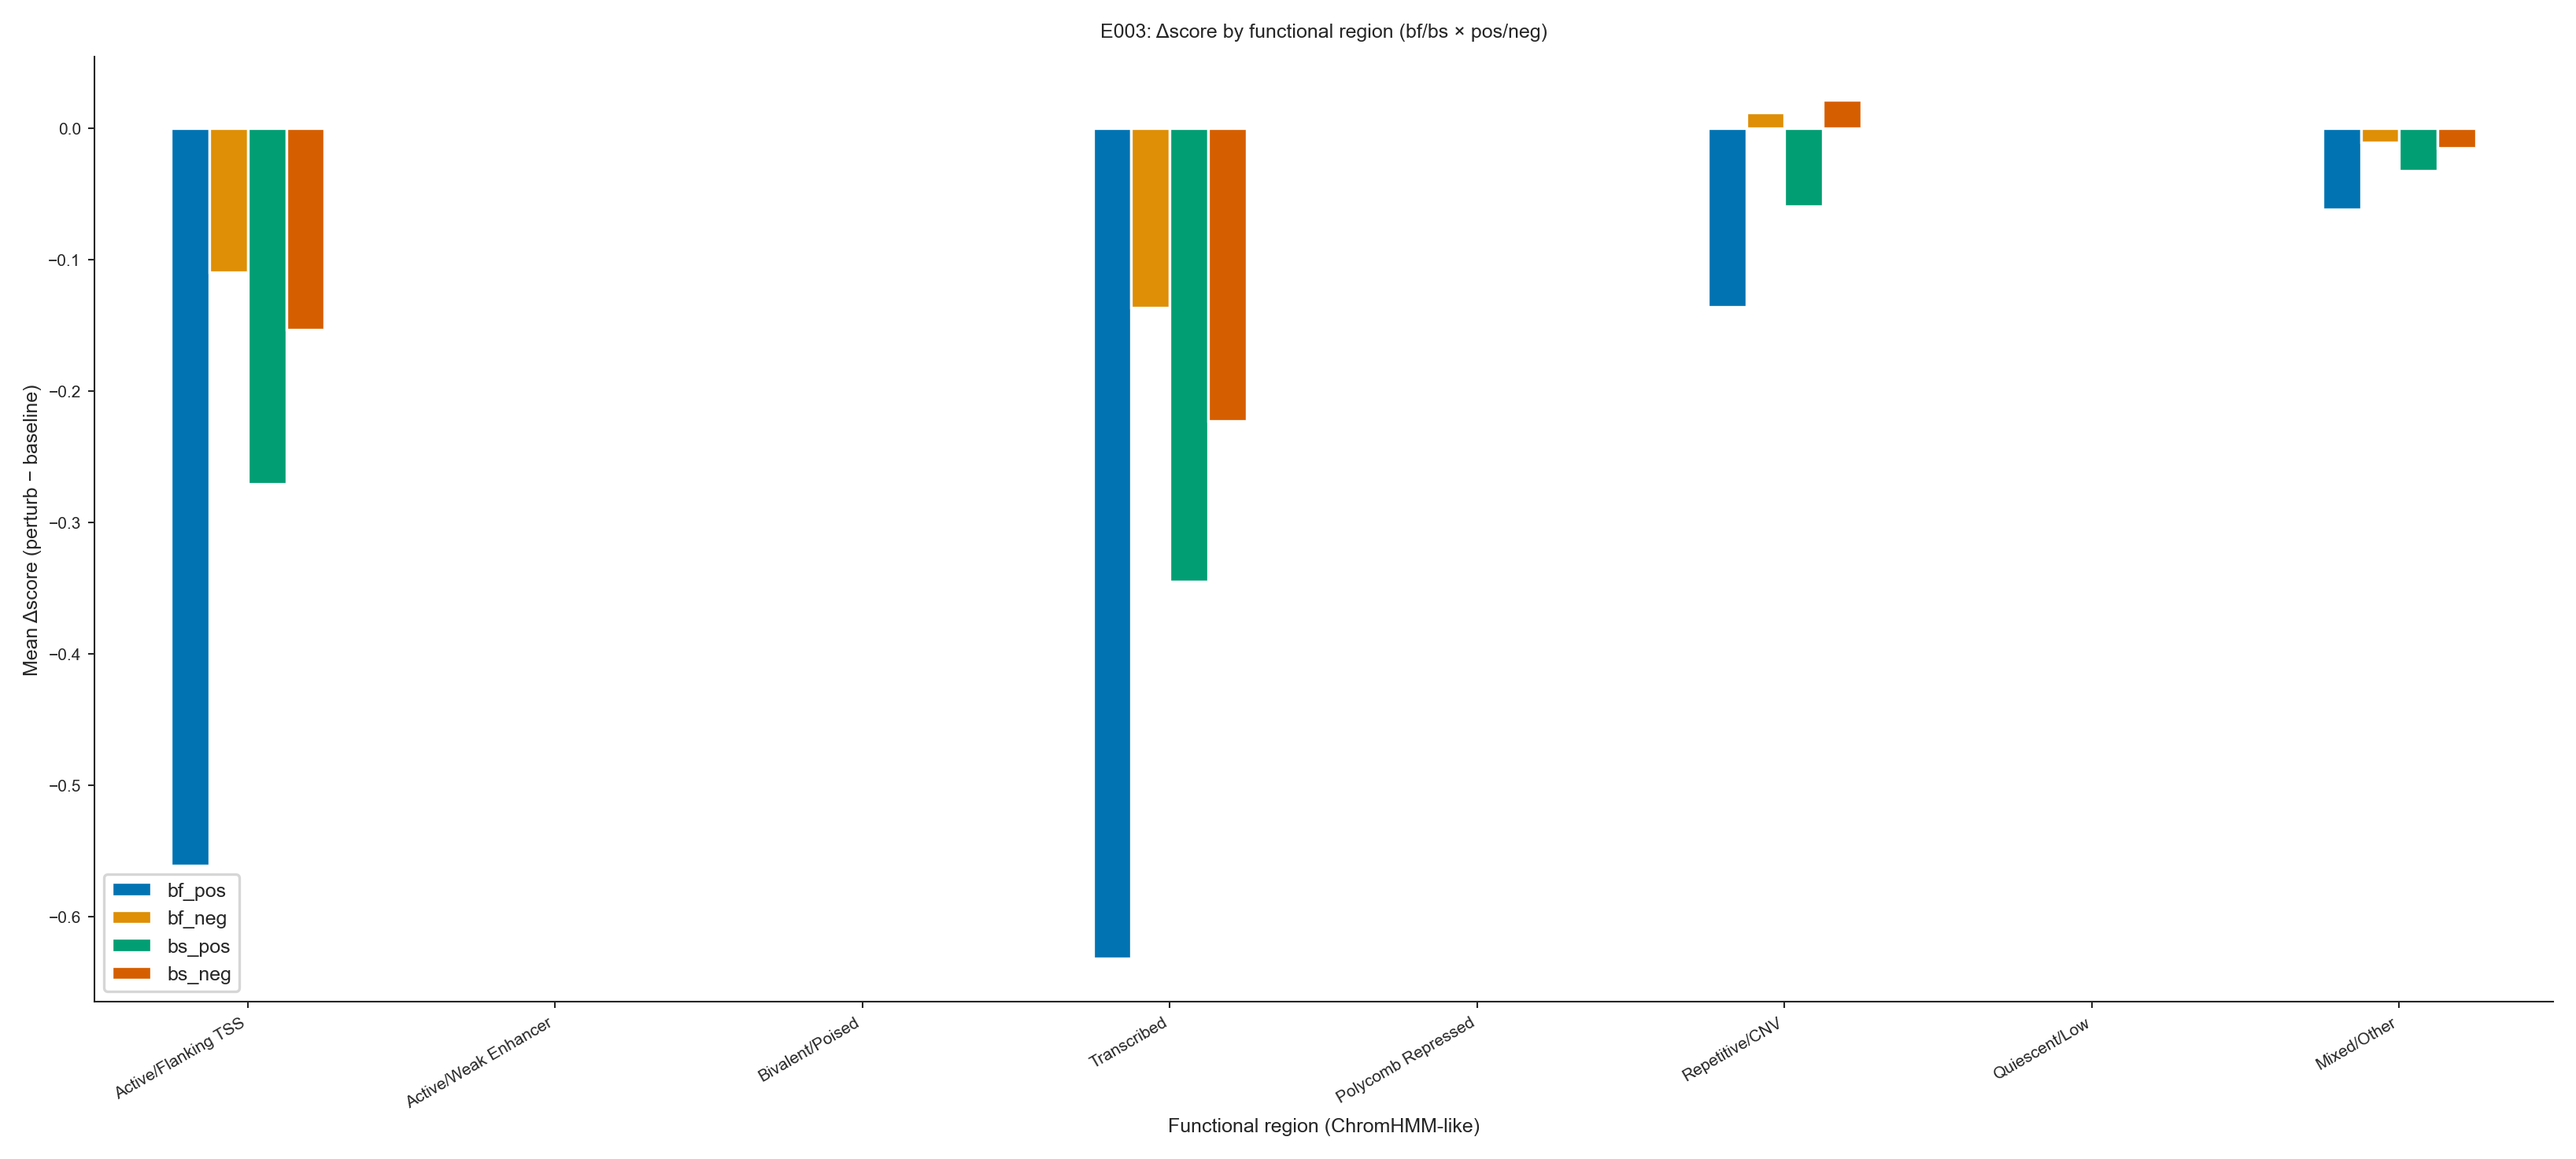

KeyError: Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50],
      dtype='int64', name='state')

In [73]:
# ========= 依赖 =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ========= 路径（自行修改） =========
EMISS_CSV   = "chromhmm_E003/E003_chromHMM50_emissions_7marks_prob.csv"  # 50×7 emission 概率
PERTURB_CSV = "your_perturbation_results.csv"                            # 你的扰动结果（含 baseline 行）
OUT_DIR     = Path("figures_chromhmm_e003_stats")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ========= 读入数据 =========
emiss = pd.read_csv(EMISS_CSV, index_col=0)     # index=S1..S50; columns=7 marks
perturb = pd.read_csv("extra/datasets/results/perturbation_masks_mode-all.csv")  # 你的扰动结果
df = perturb[perturb["eid"]=="E003"].copy()  # 只看 E003

# ========= 组合 → 无序键（顺序无关匹配） =========
def combo_to_key(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return tuple()
    if isinstance(s, str):
        s = s.strip()
        if s == "" or s.lower()=="none":
            return tuple()
        for sep in [",", " "]:
            s = s.replace(sep, "|")
        parts = [p.strip() for p in s.split("|") if p.strip()]
        return tuple(sorted(parts))
    return tuple()

df["combo_key"] = df["masked_marks"].apply(combo_to_key)

# ========= emission → 组合键（按阈值） =========
THRESH_PRESENT = 0.5  # 与补图10d一致的“显著发射”阈值（可调）
def row_to_key(row, thresh=THRESH_PRESENT):
    present = [m for m,p in row.items() if p>=thresh]
    return tuple(sorted(present)) if present else tuple()

state2key = emiss.apply(row_to_key, axis=1)  # Series: state -> tuple key

# ========= 按补图10d逻辑进行功能区分类 =========
def classify_state(row, strong=0.6, weak=0.2):
    """
    近似补图10d的功能分区：
    - Active/Flanking TSS: H3K4me3 高 & H3K9ac>=弱（promoter-like）
    - Active/Weak Enhancer: H3K4me1 高 & H3K27ac>=弱 且 H3K4me3 低
    - Bivalent/Poised: H3K4me3 高 & H3K27me3 高
    - Repetitive/CNV: H3K9me3 高
    - Transcribed: H3K36me3 高
    - Polycomb Repressed: H3K27me3 高 & 其它激活标记弱
    - Quiescent/Low: 全都低
    - Mixed: 其余
    """
    m = row.to_dict()
    if m.get("H3K4me3",0)>strong and m.get("H3K9ac",0)>weak:
        return "Active/Flanking TSS"
    if m.get("H3K4me1",0)>strong and m.get("H3K27ac",0)>weak and m.get("H3K4me3",0)<weak:
        return "Active/Weak Enhancer"
    if m.get("H3K4me3",0)>strong and m.get("H3K27me3",0)>strong:
        return "Bivalent/Poised"
    if m.get("H3K9me3",0)>strong:
        return "Repetitive/CNV"
    if m.get("H3K36me3",0)>strong:
        return "Transcribed"
    if m.get("H3K27me3",0)>strong and all(
        m.get(x,0)<weak for x in ["H3K4me3","H3K9ac","H3K27ac","H3K4me1"]
    ):
        return "Polycomb Repressed"
    if all(v<weak for v in m.values()):
        return "Quiescent/Low"
    return "Mixed/Other"

state2group = emiss.apply(classify_state, axis=1)  # index=S1..S50 → group

# （可选）如需手工覆盖个别 state 的分组，可在这里写：
# manual_override = {"S12":"Active/Weak Enhancer", "S38":"Repetitive/CNV"}
# for s,g in manual_override.items(): state2group.loc[s] = g

# ========= baseline 与 Δscore（分别算 bf / bs） =========
baseline = df[df["combo_key"]==tuple()].set_index("gene_id")
for tgt in ["bf_label","bs_label"]:
    df[f"{tgt}_dscore"] = df[f"{tgt}_score"] - df["gene_id"].map(baseline[f"{tgt}_score"])

# ========= 先按“state 组合键”匹配所有行，再打上 state & group 标签 =========
# 先把 perturb 按 combo_key 分组缓存（提高效率）
grp_by_key = {k:g for k,g in df.groupby("combo_key")}

rows = []
for state, key in state2key.items():
    sub = grp_by_key.get(key, pd.DataFrame())
    gname = state2group.loc[state]
    if sub.empty:
        rows.append({
            "state": state, "group": gname, "masked_marks": "|".join(key) if key else "None",
            "bf_pos": np.nan, "bf_neg": np.nan, "bs_pos": np.nan, "bs_neg": np.nan,
            "n_rows": 0
        })
        continue
    # 分别在正负样本上取平均 Δscore
    rec = {
        "state": state, "group": gname, "masked_marks": "|".join(key) if key else "None",
        "bf_pos": sub.loc[sub["bf_label_label"]==1, "bf_label_dscore"].mean(),
        "bf_neg": sub.loc[sub["bf_label_label"]==0, "bf_label_dscore"].mean(),
        "bs_pos": sub.loc[sub["bs_label_label"]==1, "bs_label_dscore"].mean(),
        "bs_neg": sub.loc[sub["bs_label_label"]==0, "bs_label_dscore"].mean(),
        "n_rows": len(sub)
    }
    rows.append(rec)

by_state = pd.DataFrame(rows).set_index("state")
by_state.to_csv(OUT_DIR/"E003_by_state_posneg.csv")

# ========= 汇总到“功能区域”层面（把所有匹配到的 state 的样本池在一起再求平均） =========
# 方式A：直接把所有 state 的样本拼起来再 groupby 功能区（推荐，样本量加权）
df_with_group = []
for state, key in state2key.items():
    sub = grp_by_key.get(key, pd.DataFrame()).copy()
    if sub.empty: continue
    sub["state"] = state
    sub["group"] = state2group.loc[state]
    df_with_group.append(sub)

if len(df_with_group):
    pool = pd.concat(df_with_group, axis=0, ignore_index=True)
    # 功能区 × (bf+/bf−/bs+/bs−) 的平均 Δscore
    agg_fun = {
        "bf_label_dscore": ["mean"],
        "bs_label_dscore": ["mean"],
    }
    # 分别在正负样本上聚合
    pool["bf_posneg"] = np.where(pool["bf_label_label"]==1, "bf_pos", "bf_neg")
    pool["bs_posneg"] = np.where(pool["bs_label_label"]==1, "bs_pos", "bs_neg")

    bf_pos = pool.loc[pool["bf_label_label"]==1].groupby("group")["bf_label_dscore"].mean().rename("bf_pos")
    bf_neg = pool.loc[pool["bf_label_label"]==0].groupby("group")["bf_label_dscore"].mean().rename("bf_neg")
    bs_pos = pool.loc[pool["bs_label_label"]==1].groupby("group")["bs_label_dscore"].mean().rename("bs_pos")
    bs_neg = pool.loc[pool["bs_label_label"]==0].groupby("group")["bs_label_dscore"].mean().rename("bs_neg")

    by_group = pd.concat([bf_pos, bf_neg, bs_pos, bs_neg], axis=1)
else:
    # 如果没有匹配上任何组合（极少见），退化为按 state 平均后再均值
    by_group = by_state.groupby("group")[["bf_pos","bf_neg","bs_pos","bs_neg"]].mean()

# 指定功能区顺序（与补图10d一致的逻辑）
group_order = [
    "Active/Flanking TSS",
    "Active/Weak Enhancer",
    "Bivalent/Poised",
    "Transcribed",
    "Polycomb Repressed",
    "Repetitive/CNV",
    "Quiescent/Low",
    "Mixed/Other",
]
by_group = by_group.reindex(group_order)
by_group.to_csv(OUT_DIR/"E003_by_group_posneg.csv")

# ========= 作图：区域层面的四张条形图 =========
plt.figure(figsize=(11, 5))
ax = plt.gca()
by_group.plot(kind="bar", ax=ax)
ax.set_ylabel("Mean Δscore (perturb − baseline)")
ax.set_xlabel("Functional region (ChromHMM-like)")
ax.set_title("E003: Δscore by functional region (bf/bs × pos/neg)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR/"E003_region_bar_posneg.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR/"E003_region_bar_posneg.eps", format="eps", bbox_inches="tight")
plt.show()

# ========= 可选：state × 四列 Δscore 的热图（按功能区排序显示） =========
# 先把 state 排序：先按功能区，再按 state 编号
by_state2 = by_state.copy()
by_state2["group_order"] = by_state2["group"].map({g:i for i,g in enumerate(group_order)})
by_state2 = by_state2.sort_values(["group_order", by_state2.index])

heat = by_state2[["bf_pos","bf_neg","bs_pos","bs_neg"]]
vmax = np.nanmax(np.abs(heat.values))
vmax = max(vmax, 1e-3)
plt.figure(figsize=(7, 10))
sns.heatmap(heat, cmap="bwr", center=0, vmin=-vmax, vmax=vmax, cbar_kws={"label":"Mean Δscore"})
plt.title("E003: Δscore by state (sorted by region)")
plt.xlabel("Targets (pos/neg)")
plt.ylabel("States (grouped)")
plt.tight_layout()
plt.savefig(OUT_DIR/"E003_state_heat_posneg.pdf", bbox_inches="tight")
plt.savefig(OUT_DIR/"E003_state_heat_posneg.eps", format="eps", bbox_inches="tight")
plt.show()

print("[Saved]", OUT_DIR)